In [155]:
# Import required packages

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from numpy import trapz
from scipy.stats import gamma,norm,fisk,wilcoxon
from sklearn.cluster import KMeans
import sys
from pathlib import Path
import logging
from matplotlib.patches import Patch

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))


In [39]:
# Configuration
config = {
    'casr_input_data': project_root / 'data' / 'input_data' / 'CaSR_SWE' / 'bow_casrv3.2_SWE_P_data.csv',
    'shapefile': project_root / 'data' / 'input_data' / 'shapefiles'/'BowRiverBasin'/'Bow_elevation_combined.shp',
    'canswe_original_data' : project_root / 'data' / 'output_data' / 'for_paper'/'FROSTBITE' / 'bow_canswe_selected_fixed.nc',
    'gap_filled_canswe_data' : project_root / 'data' / 'output_data' / 'for_paper'/'FROSTBITE' /'bow_swe_gapfilled_data_only.nc',
    'output_dir': project_root / 'data' / 'output_data' / 'for_paper'/'datasets',
    'SWEI_output_dir': project_root / 'data' / 'output_data' / 'for_paper'/'SWEI',
    'classification_output_dir': project_root / 'data' / 'output_data' / 'for_paper'/'SD_classification',
    'SPI_output_dir': project_root / 'data' / 'output_data' / 'for_paper'/'SPI',
    'SWEI_plots': project_root / 'data' / 'output_plots' / 'for_paper'/'SWEI',
    'classification_plots': project_root / 'data' / 'output_plots'/'for_paper'/'SD_classification',
    'SPI_plots': project_root / 'data' / 'output_plots' / 'for_paper'/'SPI',
}

# Data Loading

In [40]:
# Load shapefile for Bow Basin
bow_basin = gpd.read_file(config['shapefile'])
display(bow_basin.head())

# Load original CanSWE data
canswe_data = xr.open_dataset(config['canswe_original_data'])
canswe_data = canswe_data.to_dataframe().reset_index()
canswe_data['time'] = pd.to_datetime(canswe_data['time'])
display(canswe_data.head())

# Load gap-filled CanSWE data
gap_filled_canswe_data = xr.open_dataset(config['gap_filled_canswe_data'])
gap_filled_canswe_df = gap_filled_canswe_data.to_dataframe().reset_index()
gap_filled_canswe_df['time'] = pd.to_datetime(gap_filled_canswe_df['time'])
display(gap_filled_canswe_df.head())

# Load CaSR data
casr_data = pd.read_csv(config['casr_input_data'])
casr_data['time'] = pd.to_datetime(casr_data['time'])
display(casr_data.head())



,PROVCD_1,VALDATE,EDITION,DATASETNAM,VERSION,COMPLEVEL,WSCMDA,WSCSDA,WSCSSDA,FDA,...,WSCSSDANAM,min,max,mean,count,std,median,PROVCD_2,elev_class,geometry
0,AB,20070208,1,05BM000,0,NHN-CL1,05,05B,05BM,05BM,...,Lower Bow - Crowfoot,776.0,1177.0,953.688214,9897452,71.132927,944.0,NaN,500_1000m,"POLYGON ((-112.58577 51.23024, -112.58519 51.2..."
1,AB,20070130,1,05BN000,0,NHN-CL1,05,05B,05BN,05BN,...,Lower Bow - Mouth,700.0,998.0,772.376015,9312616,32.852467,764.0,NaN,500_1000m,"POLYGON ((-112.49620 50.71881, -112.49566 50.7..."
2,AB,20070226,1,05BH000,0,NHN-CL1,05,05B,05BH,05BH,...,Central Bow - Jumpingpond,1038.0,2479.0,1259.913722,4121228,176.434021,1227.0,NaN,1000_1500m,"POLYGON ((-113.93263 51.12563, -113.93288 51.1..."
3,AB,20070228,1,05BK000,0,NHN-CL1,05,05B,05BK,05BK,...,Fish (Alta.),981.0,1777.0,1226.170423,1151005,126.086335,1194.0,NaN,1000_1500m,"POLYGON ((-114.10188 50.95504, -114.09750 50.9..."
4,AB,20070302,1,05BE000,0,NHN-CL1,05,05B,05BE,05BE,...,Upper Bow - Policeman,1146.0,3054.0,1601.837836,1655101,376.052387,1437.0,NaN,1500_2000m,"POLYGON ((-114.72215 51.33033, -114.72235 51.3..."


,time,station_id,snw,lat,lon,station_name,Elevation_Category
0,1980-01-02,ALE-05BA801,NaN,51.423084,-116.183690,BOW RIVER,1500_2000m
1,1980-01-02,ALE-05BA802,NaN,51.437960,-116.181274,PIPESTONE UPPER,1500_2000m
2,1980-01-02,ALE-05BA806,NaN,51.416620,-116.238270,MIRROR LAKE,2000_2500m
3,1980-01-02,ALE-05BA808,NaN,51.424427,-116.213310,CHATEAU LAWN,1500_2000m
4,1980-01-02,ALE-05BA810,NaN,51.474090,-116.102745,PTARMIGAN HUT,2000_2500m


,time,station_id,lat,lon,station_name,SWE
0,1980-01-01,ALE-05BA801,51.423084,-116.183690,BOW RIVER,NaN
1,1980-01-01,ALE-05BA802,51.437960,-116.181274,PIPESTONE UPPER,NaN
2,1980-01-01,ALE-05BA806,51.416620,-116.238270,MIRROR LAKE,NaN
3,1980-01-01,ALE-05BA808,51.424427,-116.213310,CHATEAU LAWN,NaN
4,1980-01-01,ALE-05BA810,51.474090,-116.102745,PTARMIGAN HUT,NaN


,Grid_id,time,lon,lat,Precipitation,SWE,Elevation_Category
0,1,1980-10-10,-116.1380,51.3346,0.009879,0.878418,2000_2500m
1,1,1982-07-19,-116.1380,51.3346,2.765854,0.515625,2000_2500m
2,2,1983-10-12,-116.1875,51.4191,0.023846,6.875000,2000_2500m
3,2,1980-12-11,-116.1875,51.4191,4.578907,118.125000,2000_2500m
4,2,1981-07-21,-116.1875,51.4191,5.400473,0.000000,2000_2500m


In [176]:
#print columns in bow basin shapefile
print(bow_basin.columns)

Index(['PROVCD_1', 'VALDATE', 'EDITION', 'DATASETNAM', 'VERSION', 'COMPLEVEL',
       'WSCMDA', 'WSCSDA', 'WSCSSDA', 'FDA', 'OCEAN', 'WSCMDANAME',
       'WSCSDANAME', 'WSCSSDANAM', 'min', 'max', 'mean', 'count', 'std',
       'median', 'PROVCD_2', 'elev_class', 'geometry'],
      dtype='object')


In [41]:
# print all the staion_ids and the assigned elevation_categories. drop duplicates
print(canswe_data[['station_id', 'Elevation_Category']].drop_duplicates().count())
print(canswe_data[['station_id', 'Elevation_Category']].drop_duplicates()['Elevation_Category'].unique())

#print the number of stations in each elevation category
print(canswe_data[['station_id', 'Elevation_Category']].drop_duplicates()['Elevation_Category'].value_counts())

# print all the staion_ids and the assigned elevation_categories. drop duplicates
print(gap_filled_canswe_df[['station_id']].drop_duplicates().count())



station_id            48
Elevation_Category    48
dtype: int64
['1500_2000m' '2000_2500m']
Elevation_Category
2000_2500m    34
1500_2000m    14
Name: count, dtype: int64
station_id    48
dtype: int64


In [42]:
# adda new column to original canswe data with the gap-filled values
combined_canswe = canswe_data.merge(gap_filled_canswe_df[['time', 'station_id', 'SWE']], on=['time', 'station_id'], how='left')
# Rename columns for clarity
combined_canswe.rename(columns={'snw': 'Original_CanSWE', 'SWE': 'Gap_Filled_CanSWE'}, inplace=True) 

display(combined_canswe)

# print all the staion_ids and the assigned elevation_categories. drop duplicates
print(combined_canswe[['station_id', 'Elevation_Category']].drop_duplicates().count())
print(combined_canswe[['station_id', 'Elevation_Category']].drop_duplicates()['Elevation_Category'].unique())

# Save combined CanSWE data
#output_dir = config['output_dir']
#output_dir.mkdir(parents=True, exist_ok=True)
#combined_canswe.to_csv(output_dir / 'bow_combined_canswe_gapfilled_data.csv', index=False)

,time,station_id,Original_CanSWE,lat,lon,station_name,Elevation_Category,Gap_Filled_CanSWE
0,1980-01-02,ALE-05BA801,NaN,51.423084,-116.183690,BOW RIVER,1500_2000m,NaN
1,1980-01-02,ALE-05BA802,NaN,51.437960,-116.181274,PIPESTONE UPPER,1500_2000m,NaN
2,1980-01-02,ALE-05BA806,NaN,51.416620,-116.238270,MIRROR LAKE,2000_2500m,NaN
3,1980-01-02,ALE-05BA808,NaN,51.424427,-116.213310,CHATEAU LAWN,1500_2000m,NaN
4,1980-01-02,ALE-05BA810,NaN,51.474090,-116.102745,PTARMIGAN HUT,2000_2500m,NaN
...,...,...,...,...,...,...,...,...
670363,2024-07-31,UU-MC-LvlFrst,NaN,50.946804,-115.146805,LevelForest,1500_2000m,NaN
670364,2024-07-31,UU-MC-UpFrst,NaN,50.956860,-115.175060,Upper_Forest,1500_2000m,NaN
670365,2024-07-31,UU-MC-UppClr,NaN,50.956570,-115.175440,Upper_Clearing,1500_2000m,NaN
670366,2024-07-31,UU-MC-VVClr,NaN,50.970898,-115.172120,VistaView_clearing,1500_2000m,NaN


station_id            48
Elevation_Category    48
dtype: int64
['1500_2000m' '2000_2500m']


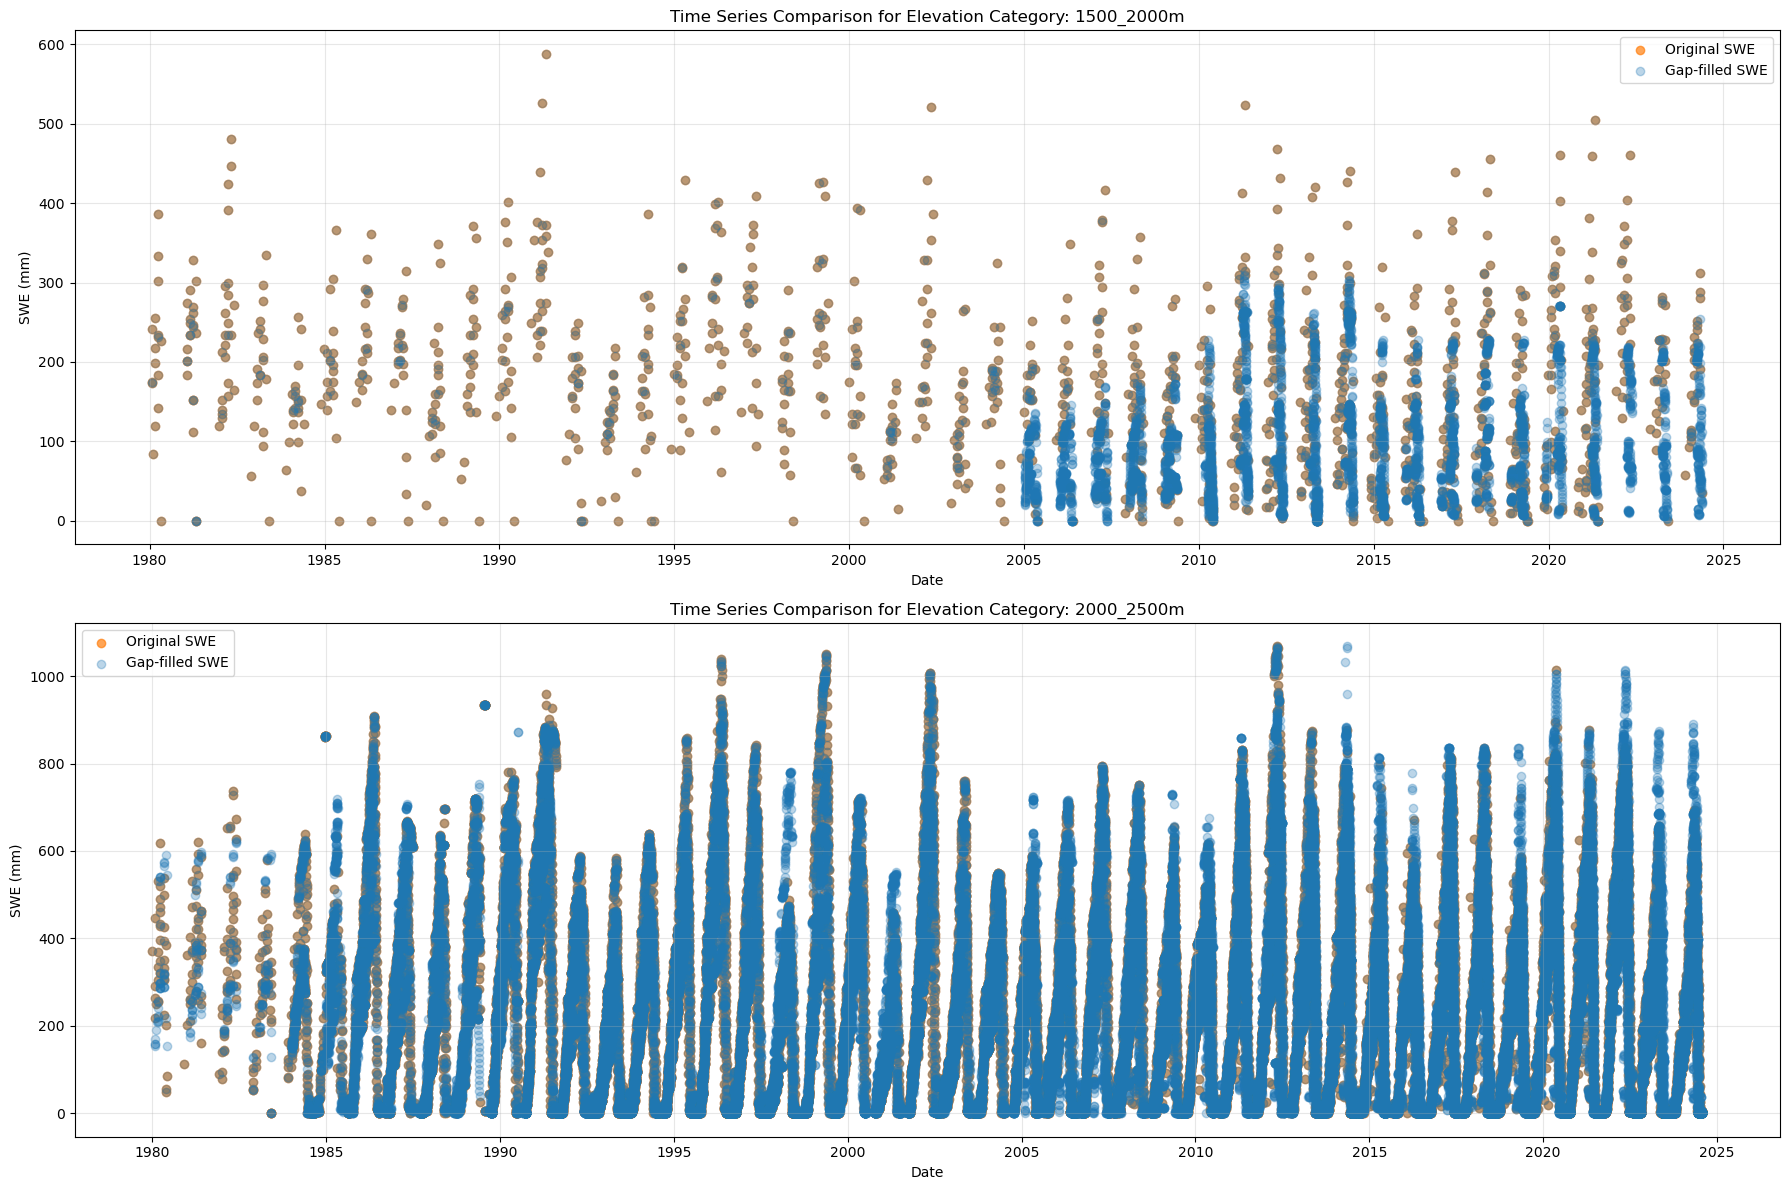

In [6]:
# Plot time series for each elevation category comparing Original_SWE and Gap_filled_SWE
elev_categories = [ '1500_2000m', '2000_2500m']

plt.figure(figsize=(18, 12))
for i, elev_cat in enumerate(elev_categories, 1):
    plt.subplot(len(elev_categories), 1, i)

    # Filter data for the current elevation category and sort by time
    df_cat = combined_canswe.loc[combined_canswe['Elevation_Category'] == elev_cat].sort_values('time')

    # Plot Original SWE (x and y have matching lengths)
    plt.scatter(
        df_cat['time'],
        df_cat['Original_CanSWE'],
        label='Original SWE',
        color='tab:orange',
        alpha=0.7
    )


    # Plot Gap-filled SWE (x and y have matching lengths)
    plt.scatter(
        df_cat['time'],
        df_cat['Gap_Filled_CanSWE'],
        label='Gap-filled SWE',
        color='tab:blue',
        alpha=0.3
    )



    plt.title(f'Time Series Comparison for Elevation Category: {elev_cat}')
    plt.xlabel('Date')
    plt.ylabel('SWE (mm)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select data for the season
1. Winter months October to May data are selected

In [43]:
# Enforce allowed seasonal-year range inside the selector
def select_seasonal_data(ts, start_month, end_month, min_year, max_year):
    month = ts.month
    year = ts.year
    if month >= start_month:
        seasonal_year = year
    elif month <= end_month:
        seasonal_year = year - 1
    else:
        return np.nan
    return seasonal_year if (min_year <= seasonal_year <= max_year) else np.nan

# For CanSWE data
combined_canswe['Seasonal_Year'] = combined_canswe['time'].apply(
    lambda ts: select_seasonal_data(ts, start_month=10, end_month=5, min_year=1980, max_year=2023)
)

# Remove rows where Seasonal_Year is NaN (outside the allowed data range)
combined_canswe = combined_canswe.dropna(subset=['Seasonal_Year'])

# Save the final combined CanSWE data with Seasonal_Year column
#combined_canswe.to_csv(output_dir / 'bow_combined_canswe_gapfilled_data_with_seasonal_year.csv', index=False)

# Display final combined CanSWE data
display(combined_canswe)

,time,station_id,Original_CanSWE,lat,lon,station_name,Elevation_Category,Gap_Filled_CanSWE,Seasonal_Year
960,1980-11-27,ALE-05BA801,NaN,51.423084,-116.183690,BOW RIVER,1500_2000m,NaN,1980.0
961,1980-11-27,ALE-05BA802,NaN,51.437960,-116.181274,PIPESTONE UPPER,1500_2000m,NaN,1980.0
962,1980-11-27,ALE-05BA806,NaN,51.416620,-116.238270,MIRROR LAKE,2000_2500m,NaN,1980.0
963,1980-11-27,ALE-05BA808,NaN,51.424427,-116.213310,CHATEAU LAWN,1500_2000m,NaN,1980.0
964,1980-11-27,ALE-05BA810,NaN,51.474090,-116.102745,PTARMIGAN HUT,2000_2500m,NaN,1980.0
...,...,...,...,...,...,...,...,...,...
667435,2024-05-31,UU-MC-LvlFrst,NaN,50.946804,-115.146805,LevelForest,1500_2000m,NaN,2023.0
667436,2024-05-31,UU-MC-UpFrst,NaN,50.956860,-115.175060,Upper_Forest,1500_2000m,NaN,2023.0
667437,2024-05-31,UU-MC-UppClr,NaN,50.956570,-115.175440,Upper_Clearing,1500_2000m,NaN,2023.0
667438,2024-05-31,UU-MC-VVClr,NaN,50.970898,-115.172120,VistaView_clearing,1500_2000m,NaN,2023.0


In [45]:
# For CaSR data
casr_data['Seasonal_Year'] = casr_data['time'].apply(
    lambda ts: select_seasonal_data(ts, start_month=10, end_month=5, min_year=1980, max_year=2023)
)
# Remove rows where Seasonal_Year is NaN (outside the allowed data range)
casr_data = casr_data.dropna(subset=['Seasonal_Year'])

# rename Grid_id to station_id in casr_data
casr_data.rename(columns={'Grid_id': 'station_id'}, inplace=True)

#save the final CaSR data with Seasonal_Year column
#casr_data.to_csv(output_dir / 'bow_casr_data_with_seasonal_year.csv', index=False)

# Display final CaSR data
display(casr_data)

,station_id,time,lon,lat,Precipitation,SWE,Elevation_Category,Seasonal_Year
0,1,1980-10-10,-116.1380,51.3346,0.009879,0.878418,2000_2500m,1980
2,2,1983-10-12,-116.1875,51.4191,0.023846,6.875000,2000_2500m,1983
3,2,1980-12-11,-116.1875,51.4191,4.578907,118.125000,2000_2500m,1980
5,2,1982-10-29,-116.1875,51.4191,1.777088,23.125000,2000_2500m,1982
6,2,1982-01-18,-116.1875,51.4191,1.890419,145.000000,2000_2500m,1981
...,...,...,...,...,...,...,...,...
4224297,257,2024-02-22,-111.6202,50.0960,0.011238,6.250000,500_1000m,2023
4224298,257,2024-03-19,-111.6202,50.0960,0.000257,0.000488,500_1000m,2023
4224301,257,2024-01-06,-111.6202,50.0960,0.135581,0.625000,500_1000m,2023
4224302,257,2024-05-17,-111.6202,50.0960,6.328805,0.000000,500_1000m,2023


# Peak SWE

# 1. CanSWE and gapfilled 

In [9]:
# make sure time is datetime
combined_canswe['time'] = pd.to_datetime(combined_canswe['time'])


def get_peak_by_group(df, value_col, prefix):
    """
    Find peak SWE and peak SWE date for each station_id and Seasonal_Year
    for a given SWE column.
    """
    # keep only rows where the SWE column is available
    valid = df.dropna(subset=[value_col]).copy()

    # if everything is missing, return empty structure
    if valid.empty:
        return (
            df[['station_id', 'Seasonal_Year']]
            .drop_duplicates()
            .assign(**{
                f'{prefix}_Peak_SWE': np.nan,
                f'{prefix}_Peak_SWE_Date': pd.NaT
            })
        )

    # index of max SWE within each station-year group
    peak_idx = (
        valid.groupby(['station_id', 'Seasonal_Year'])[value_col]
        .idxmax()
        
    )

    # extract rows at peak
    peak_df = (
        valid.loc[peak_idx, ['station_id', 'Seasonal_Year', value_col, 'time']]
        .rename(columns={
            value_col: f'{prefix}_Peak_SWE',
            'time': f'{prefix}_Peak_SWE_Date'
        })
        .reset_index(drop=True)
    )

    # keep all groups, including those with all-NaN values
    all_groups = df[['station_id', 'Seasonal_Year']].drop_duplicates()

    peak_df = all_groups.merge(
        peak_df,
        on=['station_id', 'Seasonal_Year'],
        how='left'
    )

    return peak_df


# ---- run for original SWE ----

original_peak = get_peak_by_group(
    combined_canswe,
    value_col='Original_CanSWE',
    prefix='Original'
)

# ---- run for gap-filled SWE ----
gapfilled_peak = get_peak_by_group(
    combined_canswe,
    value_col='Gap_Filled_CanSWE',
    prefix='GapFilled'
)

# ---- merge both results together ----
peak_swe_data = original_peak.merge(
    gapfilled_peak,
    on=['station_id', 'Seasonal_Year'],
    how='outer'
)

# add station metadata
meta_cols = [c for c in ['station_id', 'Elevation_Category', 'station_name', 'lat', 'lon'] if c in combined_canswe.columns]

if len(meta_cols) > 1:
    station_meta = combined_canswe[meta_cols].drop_duplicates(subset='station_id')
    peak_swe_data = peak_swe_data.merge(station_meta, on='station_id', how='left')

display(peak_swe_data)


,station_id,Seasonal_Year,Original_Peak_SWE,Original_Peak_SWE_Date,GapFilled_Peak_SWE,GapFilled_Peak_SWE_Date,Elevation_Category,station_name,lat,lon
0,ALE-05BA801,1980.0,244.0,1981-04-01,244.00,1981-04-01,1500_2000m,BOW RIVER,51.423084,-116.183690
1,ALE-05BA802,1980.0,246.0,1981-04-01,246.00,1981-04-01,1500_2000m,PIPESTONE UPPER,51.437960,-116.181274
2,ALE-05BA806,1980.0,318.0,1981-04-01,318.00,1981-04-01,2000_2500m,MIRROR LAKE,51.416620,-116.238270
3,ALE-05BA808,1980.0,328.0,1981-04-01,328.00,1981-04-01,1500_2000m,CHATEAU LAWN,51.424427,-116.213310
4,ALE-05BA810,1980.0,447.0,1981-04-29,447.00,1981-04-29,2000_2500m,PTARMIGAN HUT,51.474090,-116.102745
...,...,...,...,...,...,...,...,...,...,...
2107,UU-MC-LvlFrst,2023.0,NaN,NaT,15.51,2024-04-10,1500_2000m,LevelForest,50.946804,-115.146805
2108,UU-MC-UpFrst,2023.0,NaN,NaT,92.44,2024-03-27,1500_2000m,Upper_Forest,50.956860,-115.175060
2109,UU-MC-UppClr,2023.0,NaN,NaT,214.51,2024-04-13,1500_2000m,Upper_Clearing,50.956570,-115.175440
2110,UU-MC-VVClr,2023.0,NaN,NaT,253.67,2024-05-02,1500_2000m,VistaView_clearing,50.970898,-115.172120


In [183]:
# ensure datetime
peak_swe_data['Original_Peak_SWE_Date'] = pd.to_datetime(peak_swe_data['Original_Peak_SWE_Date'])
peak_swe_data['GapFilled_Peak_SWE_Date'] = pd.to_datetime(peak_swe_data['GapFilled_Peak_SWE_Date'])

# convert peak date to day-of-year
peak_swe_data['Original_Peak_DOY'] = peak_swe_data['Original_Peak_SWE_Date'].dt.dayofyear
peak_swe_data['GapFilled_Peak_DOY'] = peak_swe_data['GapFilled_Peak_SWE_Date'].dt.dayofyear

# aggregate by season year and elevation category
seasonal_elev_avg = (
    peak_swe_data
    .groupby(['Seasonal_Year', 'Elevation_Category'], dropna=False)
    .agg(
        Original_avg_peak_SWE=('Original_Peak_SWE', 'mean'),
        Original_avg_peak_DOY=('Original_Peak_DOY', 'mean'),
        GapFilled_avg_peak_SWE=('GapFilled_Peak_SWE', 'mean'),
        GapFilled_avg_peak_DOY=('GapFilled_Peak_DOY', 'mean')
    )
    .reset_index()
)

# reshape to wide format
seasonal_elev_avg_wide = seasonal_elev_avg.pivot(
    index='Seasonal_Year',
    columns='Elevation_Category',
    values=[
        'Original_avg_peak_SWE',
        'Original_avg_peak_DOY',
        'GapFilled_avg_peak_SWE',
        'GapFilled_avg_peak_DOY'
    ]
)

# flatten multi-index columns
seasonal_elev_avg_wide.columns = [
    f'{elev}_{metric}'
    for metric, elev in seasonal_elev_avg_wide.columns
]

# convert DOY back to datetime for easier plotting (using a common year like 2000)
#for col in seasonal_elev_avg_wide.columns:
 #   if 'DOY' in col:
 #       seasonal_elev_avg_wide[col] = pd.to_datetime(
 #           seasonal_elev_avg_wide[col].fillna(0).astype(int),
 #           format='%j',
 #           errors='coerce'
 #       ).dt.strftime('%Y-%m-%d')

seasonal_elev_avg_wide = seasonal_elev_avg_wide.reset_index()

display(seasonal_elev_avg_wide.head())

C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_33244\49338484.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Seasonal_Year', 'Elevation_Category'], dropna=False)


,Seasonal_Year,1500_2000m_Original_avg_peak_SWE,2000_2500m_Original_avg_peak_SWE,1500_2000m_Original_avg_peak_DOY,2000_2500m_Original_avg_peak_DOY,1500_2000m_GapFilled_avg_peak_SWE,2000_2500m_GapFilled_avg_peak_SWE,1500_2000m_GapFilled_avg_peak_DOY,2000_2500m_GapFilled_avg_peak_DOY
0,1980.0,224.750000,443.250000,93.875000,114.000000,224.750000,435.830000,93.875000,117.200000
1,1981.0,290.500000,495.083333,96.875000,118.083333,290.500000,480.514667,96.875000,120.200000
2,1982.0,208.000000,389.000000,91.857143,105.083333,208.000000,393.221333,91.857143,109.666667
3,1983.0,162.571429,406.492188,79.857143,130.062500,162.571429,406.492188,79.857143,130.062500
4,1984.0,219.714286,442.665611,87.428571,126.722222,219.714286,479.007895,87.428571,131.000000


In [179]:
# 30 year avegage for each elevation category 1991-2020
elev_categories = ['1500_2000m', '2000_2500m']
for elev_cat in elev_categories:
    original_avg_swe = seasonal_elev_avg_wide.loc[
        (seasonal_elev_avg_wide['Seasonal_Year'] >= 1980) &
        (seasonal_elev_avg_wide['Seasonal_Year'] <= 2023),
        f'{elev_cat}_Original_avg_peak_SWE'
    ].mean()

    gapfilled_avg_swe = seasonal_elev_avg_wide.loc[
        (seasonal_elev_avg_wide['Seasonal_Year'] >= 1980) &
        (seasonal_elev_avg_wide['Seasonal_Year'] <= 2023),
        f'{elev_cat}_GapFilled_avg_peak_SWE'
    ].mean()

    print(f'Elevation Category: {elev_cat}')
    print(f'30-year Average Original Peak SWE (1980-2023): {original_avg_swe:.2f} mm')
    print(f'30-year Average Gap-filled Peak SWE (1980-2023): {gapfilled_avg_swe:.2f} mm')
    print('---')

Elevation Category: 1500_2000m
30-year Average Original Peak SWE (1980-2023): 226.97 mm
30-year Average Gap-filled Peak SWE (1980-2023): 223.49 mm
---
Elevation Category: 2000_2500m
30-year Average Original Peak SWE (1980-2023): 487.58 mm
30-year Average Gap-filled Peak SWE (1980-2023): 495.61 mm
---


In [182]:
# standard deviation for each elevation category 1980-2023
elev_categories = ['1500_2000m', '2000_2500m']
for elev_cat in elev_categories:
    original_avg_swe = seasonal_elev_avg_wide.loc[
        (seasonal_elev_avg_wide['Seasonal_Year'] >= 1980) &
        (seasonal_elev_avg_wide['Seasonal_Year'] <= 2023),
        f'{elev_cat}_GapFilled_avg_peak_SWE'
    ].std()
    print(f'Elevation Category: {elev_cat}')
    print(f'30-year Standard Deviation Gap-filled Peak SWE (1980-2023): {original_avg_swe:.2f} mm')
    print('---')

Elevation Category: 1500_2000m
30-year Standard Deviation Gap-filled Peak SWE (1980-2023): 51.39 mm
---
Elevation Category: 2000_2500m
30-year Standard Deviation Gap-filled Peak SWE (1980-2023): 92.97 mm
---


In [185]:
# average day of year for each elevation category 1980-2023
elev_categories = ['1500_2000m', '2000_2500m']
for elev_cat in elev_categories:
    original_avg_doy = seasonal_elev_avg_wide.loc[
        (seasonal_elev_avg_wide['Seasonal_Year'] >= 1980) &
        (seasonal_elev_avg_wide['Seasonal_Year'] <= 2023),
        f'{elev_cat}_GapFilled_avg_peak_DOY'
    ].mean()

    # convert average DOY back to date format for better readability
    if not np.isnan(original_avg_doy):
        avg_date = pd.to_datetime(int(original_avg_doy), format='%j', errors='coerce')
        original_avg_doy = avg_date.strftime('%B %d')  # e.g., "March 15"
        
    print(f'Elevation Category: {elev_cat}')
    print(f'30-year Average Day of Year for Gap-filled Peak SWE (1980-2023): {original_avg_doy:.2f} DOY')
    print('---')

Elevation Category: 1500_2000m


ValueError: Unknown format code 'f' for object of type 'str'

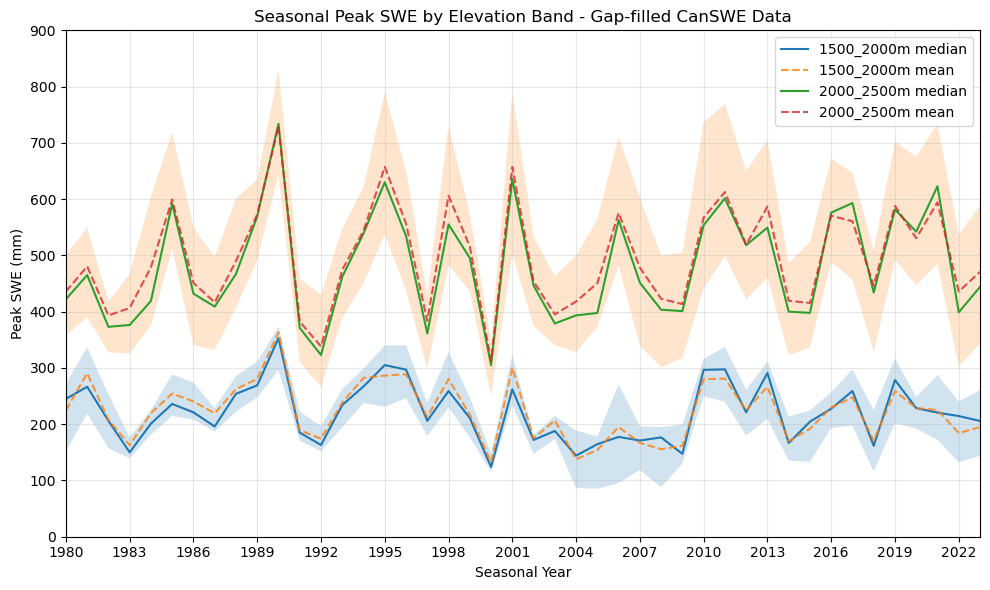

In [12]:
# ensure category order
elev_order = ['1500_2000m', '2000_2500m']
peak_swe_data['Elevation_Category'] = pd.Categorical(
    peak_swe_data['Elevation_Category'],
    categories=elev_order,
    ordered=True
)

# summarize by year and elevation
summary = (
    peak_swe_data
    .dropna(subset=['Elevation_Category', 'GapFilled_Peak_SWE'])
    .groupby(['Seasonal_Year', 'Elevation_Category'], observed=True)['GapFilled_Peak_SWE']
    .agg(
        mean='mean',
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# plot
fig, ax = plt.subplots(figsize=(10, 6))

for elev in elev_order:
    sub = summary[summary['Elevation_Category'] == elev].sort_values('Seasonal_Year')
    
    ax.plot(sub['Seasonal_Year'], sub['median'], label=f'{elev} median')
    ax.fill_between(sub['Seasonal_Year'], sub['q25'], sub['q75'], alpha=0.2)
    ax.plot(sub['Seasonal_Year'], sub['mean'], linestyle='--', alpha=0.8, label=f'{elev} mean')

ax.set_title('Seasonal Peak SWE by Elevation Band - Gap-filled CanSWE Data')
ax.set_xlabel('Seasonal Year')
ax.set_ylabel('Peak SWE (mm)')
ax.legend()
years = sorted(summary['Seasonal_Year'].unique())
ax.set_xticks(years[::3])
ax.set_xlim(1980, 2023)
ax.set_ylim(0, 900)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. CaSR peak SWE

In [13]:
#rename Grid_id to station_id for consistency
casr_data.rename(columns={'Grid_id': 'station_id'}, inplace=True)

# drop unnecessary columns from casr_data
CaSR_SWE = casr_data[['station_id', 'time','lat', 'lon', 'Seasonal_Year', 'SWE','Elevation_Category']].copy()

display(CaSR_SWE)

,station_id,time,lat,lon,Seasonal_Year,SWE,Elevation_Category
0,1,1980-10-10,51.3346,-116.1380,1980.0,0.878418,2000_2500m
2,2,1983-10-12,51.4191,-116.1875,1983.0,6.875000,2000_2500m
3,2,1980-12-11,51.4191,-116.1875,1980.0,118.125000,2000_2500m
5,2,1982-10-29,51.4191,-116.1875,1982.0,23.125000,2000_2500m
6,2,1982-01-18,51.4191,-116.1875,1981.0,145.000000,2000_2500m
...,...,...,...,...,...,...,...
4224297,257,2024-02-22,50.0960,-111.6202,2023.0,6.250000,500_1000m
4224298,257,2024-03-19,50.0960,-111.6202,2023.0,0.000488,500_1000m
4224301,257,2024-01-06,50.0960,-111.6202,2023.0,0.625000,500_1000m
4224302,257,2024-05-17,50.0960,-111.6202,2023.0,0.000000,500_1000m


In [14]:
# find peak SWE and peak SWE date for each grid_id and Seasonal_Year for CaSR SWE
CaSR_peak_SWE = get_peak_by_group(
    CaSR_SWE,
    value_col='SWE',
    prefix='CaSR'
)
meta_cols = [c for c in ['station_id', 'Elevation_Category', 'lat', 'lon'] if c in combined_canswe.columns]

if len(meta_cols) > 1:
    station_meta = casr_data[meta_cols].drop_duplicates(subset='station_id')
    CaSR_peak_SWE = CaSR_peak_SWE.merge(station_meta, on='station_id', how='left')

display(CaSR_peak_SWE.head())

,station_id,Seasonal_Year,CaSR_Peak_SWE,CaSR_Peak_SWE_Date,Elevation_Category,lat,lon
0,1,1980.0,240.62500,1981-05-12,2000_2500m,51.3346,-116.1380
1,2,1983.0,268.77148,1984-05-27,2000_2500m,51.4191,-116.1875
2,2,1980.0,303.68750,1981-05-11,2000_2500m,51.4191,-116.1875
3,2,1982.0,329.82812,1983-04-25,2000_2500m,51.4191,-116.1875
4,2,1981.0,337.12500,1982-05-09,2000_2500m,51.4191,-116.1875


In [15]:
# ensure datetime
CaSR_peak_SWE['CaSR_Peak_SWE_Date'] = pd.to_datetime(CaSR_peak_SWE['CaSR_Peak_SWE_Date'])

# convert peak date to day-of-year
CaSR_peak_SWE['CaSR_Peak_DOY'] = CaSR_peak_SWE['CaSR_Peak_SWE_Date'].dt.dayofyear
# aggregate by season year and elevation category
seasonal_elev_avg = (
    CaSR_peak_SWE
    .groupby(['Seasonal_Year', 'Elevation_Category'], dropna=False)
    .agg(
        avg_peak_SWE=('CaSR_Peak_SWE', 'mean'),
        avg_peak_DOY=('CaSR_Peak_DOY', 'mean'),
    )
    .reset_index()
)

# reshape to wide format
seasonal_elev_avg_wide_casr = seasonal_elev_avg.pivot(
    index='Seasonal_Year',
    columns='Elevation_Category',
    values=[
        'avg_peak_SWE',
        'avg_peak_DOY',
    ]
)

# flatten multi-index columns
seasonal_elev_avg_wide_casr.columns = [
    f'{elev}_{metric}'
    for metric, elev in seasonal_elev_avg_wide_casr.columns
]

# convert DOY back to datetime for easier plotting (using a common year like 2000)
for col in seasonal_elev_avg_wide_casr.columns:
    if 'DOY' in col:
        seasonal_elev_avg_wide_casr[col] = pd.to_datetime(
            seasonal_elev_avg_wide_casr[col].fillna(0).astype(int),
            format='%j',
            errors='coerce'
        ).dt.strftime('%Y-%m-%d')

seasonal_elev_avg_wide_casr = seasonal_elev_avg_wide_casr.reset_index()

display(seasonal_elev_avg_wide_casr.head())

,Seasonal_Year,1000_1500m_avg_peak_SWE,1500_2000m_avg_peak_SWE,2000_2500m_avg_peak_SWE,500_1000m_avg_peak_SWE,1000_1500m_avg_peak_DOY,1500_2000m_avg_peak_DOY,2000_2500m_avg_peak_DOY,500_1000m_avg_peak_DOY
0,1980.0,40.117253,56.006445,157.767231,41.898997,1900-11-24,1900-08-14,1900-05-09,1900-11-08
1,1981.0,29.995833,45.382143,167.513889,43.205357,1900-02-24,1900-04-03,1900-04-22,1900-03-11
2,1982.0,17.079167,41.866078,163.965798,54.445312,1900-03-08,1900-03-23,1900-04-12,1900-03-11
3,1983.0,30.662508,39.797886,139.377604,45.846590,1900-12-17,1900-08-16,1900-05-27,1900-05-10
4,1984.0,23.369173,46.719413,145.626281,71.951294,1900-07-08,1900-04-22,1900-04-24,1900-03-10


In [16]:
# 30 year avegage for each elevation category 1991-2020
elev_categories = ['500_1000m','1000_1500m','1500_2000m', '2000_2500m']
for elev_cat in elev_categories:
    casr_avg_swe = seasonal_elev_avg_wide_casr.loc[
        (seasonal_elev_avg_wide_casr['Seasonal_Year'] >= 1991) &
        (seasonal_elev_avg_wide_casr['Seasonal_Year'] <= 2020),
        f'{elev_cat}_avg_peak_SWE'
    ].mean()

    print(f'Elevation Category: {elev_cat}')
    print(f'30-year Average CaSR Peak SWE (1991-2020): {casr_avg_swe:.2f} mm')
    print('---')

Elevation Category: 500_1000m
30-year Average CaSR Peak SWE (1991-2020): 33.58 mm
---
Elevation Category: 1000_1500m
30-year Average CaSR Peak SWE (1991-2020): 33.79 mm
---
Elevation Category: 1500_2000m
30-year Average CaSR Peak SWE (1991-2020): 47.86 mm
---
Elevation Category: 2000_2500m
30-year Average CaSR Peak SWE (1991-2020): 145.83 mm
---


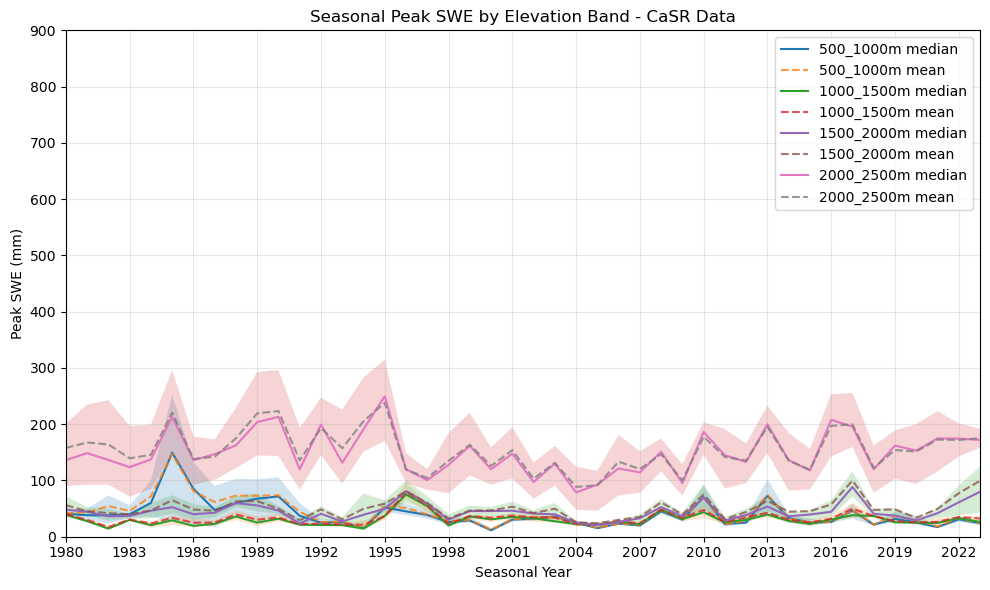

In [17]:
# ensure category order
elev_order = ['500_1000m','1000_1500m','1500_2000m', '2000_2500m']
CaSR_peak_SWE['Elevation_Category'] = pd.Categorical(
    CaSR_peak_SWE['Elevation_Category'],
    categories=elev_order,
    ordered=True
)

# summarize by year and elevation
summary = (
    CaSR_peak_SWE
    .dropna(subset=['Elevation_Category', 'CaSR_Peak_SWE'])
    .groupby(['Seasonal_Year', 'Elevation_Category'], observed=True)['CaSR_Peak_SWE']
    .agg(
        mean='mean',
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# plot
fig, ax = plt.subplots(figsize=(10, 6))

for elev in elev_order:
    sub = summary[summary['Elevation_Category'] == elev].sort_values('Seasonal_Year')
    
    ax.plot(sub['Seasonal_Year'], sub['median'], label=f'{elev} median')
    ax.fill_between(sub['Seasonal_Year'], sub['q25'], sub['q75'], alpha=0.2)
    ax.plot(sub['Seasonal_Year'], sub['mean'], linestyle='--', alpha=0.8, label=f'{elev} mean')

ax.set_title('Seasonal Peak SWE by Elevation Band - CaSR Data')
ax.set_xlabel('Seasonal Year')
ax.set_ylabel('Peak SWE (mm)')
ax.legend()
years = sorted(summary['Seasonal_Year'].unique())
ax.set_xticks(years[::3])
ax.set_xlim(1980, 2023)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 900)
plt.tight_layout()
plt.show()

In [18]:
# select CaSR_Peak_SWE > 400 mm for elevation category 2000-2500m
#CaSR_peak_SWE_filtered = CaSR_peak_SWE[CaSR_peak_SWE['CaSR_Peak_SWE'] > 250]
CaSR_peak_SWE_filtered = CaSR_peak_SWE[CaSR_peak_SWE['Elevation_Category'] == '500_1000m'].copy()

# get max for each season year
#CaSR_peak_SWE_filtered = CaSR_peak_SWE_filtered.groupby('Seasonal_Year', observed=True)['CaSR_Peak_SWE'].max().reset_index()

display(CaSR_peak_SWE_filtered)

,station_id,Seasonal_Year,CaSR_Peak_SWE,CaSR_Peak_SWE_Date,Elevation_Category,lat,lon,CaSR_Peak_DOY
322,92,1983.0,28.750000,1983-12-31,500_1000m,50.8670,-113.9136,365
323,92,1980.0,35.687500,1980-12-07,500_1000m,50.8670,-113.9136,342
356,92,1981.0,28.625000,1982-03-16,500_1000m,50.8670,-113.9136,75
357,92,1982.0,35.625000,1983-03-26,500_1000m,50.8670,-113.9136,85
358,100,1982.0,24.375000,1983-01-11,500_1000m,50.9525,-113.9583,11
...,...,...,...,...,...,...,...,...
11303,254,2022.0,21.513672,2023-04-02,500_1000m,50.0453,-111.8875,92
11304,254,2020.0,19.375000,2020-11-09,500_1000m,50.0453,-111.8875,314
11305,254,2023.0,22.500000,2024-03-25,500_1000m,50.0453,-111.8875,85
11306,256,2020.0,24.750000,2020-11-09,500_1000m,50.0097,-111.5808,314


In [19]:
def seasonal_elevation_avg_peak(
    df,
    peak_swe_col='Peak_SWE',
    peak_date_col='Peak_SWE_Date',
    season_col='Seasonal_Year',
    elev_col='Elevation_Category',
    convert_doy_to_date=True,
    reference_year=2000,
    round_swe=2,
    round_doy=0
):
    """
    Calculate average peak SWE and average peak timing for each Seasonal_Year
    and Elevation_Category, then return a wide table.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing peak SWE and peak date columns.
    peak_swe_col : str
        Column containing peak SWE values.
    peak_date_col : str
        Column containing peak SWE dates.
    season_col : str
        Column containing seasonal year.
    elev_col : str
        Column containing elevation category.
    convert_doy_to_date : bool
        If True, adds date columns converted from average DOY.
    reference_year : int
        Dummy year used for converting DOY to calendar date.
    round_swe : int
        Number of decimals for SWE columns.
    round_doy : int
        Number of decimals for DOY before optional date conversion.

    Returns
    -------
    pandas.DataFrame
    """
    out = df.copy()

    out[peak_date_col] = pd.to_datetime(out[peak_date_col], errors='coerce')
    out['Peak_DOY'] = out[peak_date_col].dt.dayofyear

    seasonal_elev_avg = (
        out.groupby([season_col, elev_col], dropna=False)
        .agg(
            avg_peak_SWE=(peak_swe_col, 'max'),
            avg_peak_DOY=('Peak_DOY', 'max')
        )
        .reset_index()
    )

    seasonal_elev_avg_wide = seasonal_elev_avg.pivot(
        index=season_col,
        columns=elev_col,
        values=['avg_peak_SWE', 'avg_peak_DOY']
    )

    seasonal_elev_avg_wide.columns = [
        f'{elev}_{metric}' for metric, elev in seasonal_elev_avg_wide.columns
    ]

    seasonal_elev_avg_wide = seasonal_elev_avg_wide.reset_index()

    swe_cols = [c for c in seasonal_elev_avg_wide.columns if 'avg_peak_SWE' in c]
    doy_cols = [c for c in seasonal_elev_avg_wide.columns if 'avg_peak_DOY' in c]

    if round_swe is not None:
        seasonal_elev_avg_wide[swe_cols] = seasonal_elev_avg_wide[swe_cols].round(round_swe)

    if round_doy is not None:
        seasonal_elev_avg_wide[doy_cols] = seasonal_elev_avg_wide[doy_cols].round(round_doy)

    if convert_doy_to_date:
        for col in doy_cols:
            seasonal_elev_avg_wide[col.replace('DOY', 'Date')] = (
                pd.to_datetime(
                    seasonal_elev_avg_wide[col],
                    format='%j',
                    errors='coerce'
                )
                .apply(lambda x: x.replace(year=reference_year) if pd.notna(x) else pd.NaT)
                .dt.strftime('%Y-%m-%d')
            )

    return seasonal_elev_avg_wide

seasonal_elev_avg_wide = seasonal_elevation_avg_peak(
    CaSR_peak_SWE,
    peak_swe_col='CaSR_Peak_SWE',
    peak_date_col='CaSR_Peak_SWE_Date'
)

display(seasonal_elev_avg_wide.head())

C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_33244\2300446497.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out.groupby([season_col, elev_col], dropna=False)


,Seasonal_Year,500_1000m_avg_peak_SWE,1000_1500m_avg_peak_SWE,1500_2000m_avg_peak_SWE,2000_2500m_avg_peak_SWE,500_1000m_avg_peak_DOY,1000_1500m_avg_peak_DOY,1500_2000m_avg_peak_DOY,2000_2500m_avg_peak_DOY,500_1000m_avg_peak_Date,1000_1500m_avg_peak_Date,1500_2000m_avg_peak_Date,2000_2500m_avg_peak_Date
0,1980.0,62.56,68.12,102.94,359.88,345.0,344.0,344.0,137.0,2000-12-11,2000-12-10,2000-12-10,2000-05-17
1,1981.0,88.75,49.50,83.38,380.38,100.0,99.0,99.0,135.0,2000-04-10,2000-04-09,2000-04-09,2000-05-15
2,1982.0,231.50,33.50,98.50,359.00,348.0,94.0,348.0,115.0,2000-12-14,2000-04-04,2000-12-14,2000-04-25
3,1983.0,96.96,37.12,103.00,332.62,365.0,365.0,365.0,365.0,2000-12-31,2000-12-31,2000-12-31,2000-12-31
4,1984.0,186.38,53.00,91.00,323.25,366.0,308.0,308.0,132.0,2000-01-01,2000-11-04,2000-11-04,2000-05-12


C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_33244\3899607428.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Seasonal_Year', 'Elevation_Category'])['SWE']


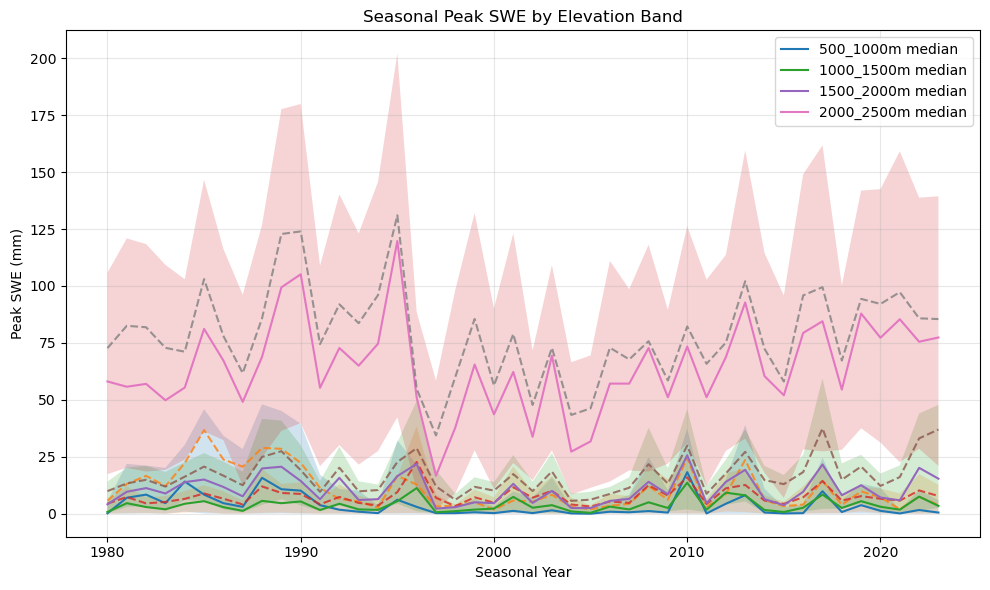

In [20]:
# ensure category order
elev_order = ['500_1000m', '1000_1500m', '1500_2000m', '2000_2500m']
CaSR_SWE['Elevation_Category'] = pd.Categorical(
    CaSR_SWE['Elevation_Category'],
    categories=elev_order,
    ordered=True
)

# summarize by year and elevation
summary = (
    CaSR_SWE
    .groupby(['Seasonal_Year', 'Elevation_Category'])['SWE']
    .agg(
        mean='mean',
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# plot
fig, ax = plt.subplots(figsize=(10, 6))

for elev in elev_order:
    sub = summary[summary['Elevation_Category'] == elev].sort_values('Seasonal_Year')
    
    ax.plot(sub['Seasonal_Year'], sub['median'], label=f'{elev} median')
    ax.fill_between(sub['Seasonal_Year'], sub['q25'], sub['q75'], alpha=0.2)
    ax.plot(sub['Seasonal_Year'], sub['mean'], linestyle='--', alpha=0.8)

ax.set_title('Seasonal Peak SWE by Elevation Band')
ax.set_xlabel('Seasonal Year')
ax.set_ylabel('Peak SWE (mm)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

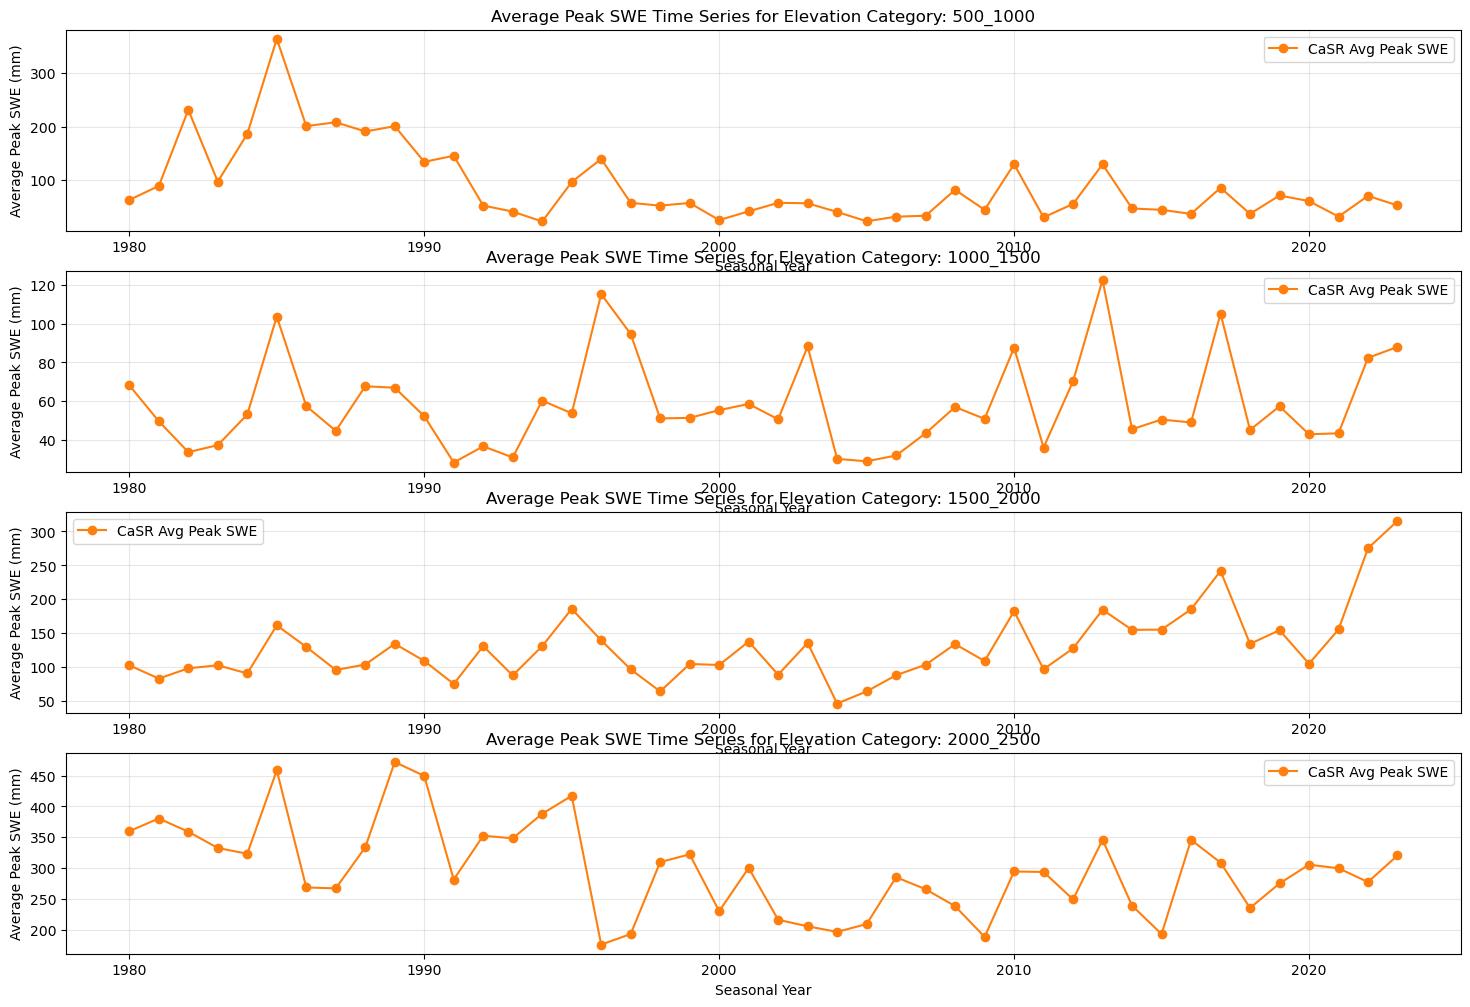

In [21]:
# plot subplots for time series of average peak SWE for each elevation category, comparing original and gap-filled

plt.figure(figsize=(18, 12))
elev_categories = [ '500_1000', '1000_1500', '1500_2000', '2000_2500']
for i, elev_cat in enumerate(elev_categories, 1):
    plt.subplot(len(elev_categories), 1, i)

    # Plot Original average peak SWE
    plt.plot(
        seasonal_elev_avg_wide['Seasonal_Year'],
        seasonal_elev_avg_wide[f'{elev_cat}m_avg_peak_SWE'],
        label='CaSR Avg Peak SWE',
        color='tab:orange',
        marker='o'
    )

    plt.title(f'Average Peak SWE Time Series for Elevation Category: {elev_cat}')
    plt.xlabel('Seasonal Year')
    plt.ylabel('Average Peak SWE (mm)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Calculate SWEI

Functions

In [61]:

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id", "lon", "lat", "Elevation_Category"]]
        .drop_duplicates("station_id")
        .set_index("station_id")
    )


def daily_to_monthly_swe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Daily SWE → monthly integrated SWE.
    Seasonal_Year is recomputed from time.
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    monthly = (
        out
        .groupby(
            ["station_id", pd.Grouper(key="time", freq="MS")],
            as_index=False
        )
        .agg(
            SWE_monthly=("SWE", "sum")
        )
    )

    # Recompute Seasonal_Year (e.g., Oct–Sep water year)
    monthly["Seasonal_Year"] = np.where(
        monthly["time"].dt.month >= 10,
        monthly["time"].dt.year,
        monthly["time"].dt.year - 1
    )

    return monthly



def rolling_integrated_swe_by_season(
    monthly_df: pd.DataFrame,
    window_months: int
) -> pd.DataFrame:
    """
    Compute rolling k‑month integrated SWE within each Seasonal_Year.

    • Rolling windows do NOT cross Seasonal_Year boundaries.
    • First (k‑1) months of each season are dropped.
    • Works for any window (3, 6, 8, …).
    """

    out = monthly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_months}mo"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_monthly"]
        .rolling(window=window_months, min_periods=window_months)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_months}mo"])



def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    # ranks with average ties
    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute SWEI for ONE station_id using calendar-month standardization.
    """
    out = df.copy()
    out["month"] = out["time"].dt.month

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for m in range(1, 13):
        idx = out["month"] == m
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue  # Near-normal (NN)

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out



def compute_swei(
    df: pd.DataFrame,
    window_months: int = 3
) -> pd.DataFrame:
    """
    End‑to‑end SWEI calculation with metadata preservation.
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily → monthly SWE
    monthly = daily_to_monthly_swe(df)

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season(monthly, window_months)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid(
                g,
                swe_col=f"SWE_{window_months}mo"
            )
        )
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei


def plot_seasonal_sswei_maps(
    swei_df,
    basin_gdf,
    config,
    window_label="3-month",
    swei_col="Avg_SWEI_3mo",
    start_year=1980,
    end_year=2024,
    month_order=(10, 11, 12, 1, 2, 3, 4, 5),
    month_names=None,
    classify_func=None,
    severity_colors=None,
    nrows=2,
    ncols=3,
    figsize=(20, 10),
    dpi=300
):
    """
    Plot seasonal SSWEI maps for each Seasonal_Year.

    Parameters
    ----------
    swei_df : pandas.DataFrame
        DataFrame containing SSWEI values with columns:
        ['Seasonal_Year', 'month', 'Elevation_Category', swei_col].
    basin_gdf : geopandas.GeoDataFrame
        Basin polygons with elevation categories column 'elev_class'.
    config : dict
        Configuration dictionary containing output directory path:
        config['SWEI_plots'].
    window_label : str
        Text label for SWEI window (e.g., '3-month', '6-month', '8-month').
    swei_col : str
        Column name containing SSWEI values.
    start_year, end_year : int
        Seasonal_Year range to plot (end_year is exclusive).
    month_order : iterable
        Ordered months for snow season (default Oct–May).
    month_names : dict
        Mapping of month number → month name.
    classify_func : callable
        Function that maps SSWEI → drought class.
    severity_colors : dict
        Mapping of drought class → color.
    nrows, ncols : int
        Subplot grid dimensions.
    figsize : tuple
        Figure size.
    dpi : int
        Output resolution.
    """

    if month_names is None:
        month_names = {
            1: "January", 2: "February", 3: "March", 4: "April",
            5: "May", 10: "October", 11: "November", 12: "December"
        }

    if classify_func is None or severity_colors is None:
        raise ValueError("Both classify_func and severity_colors must be provided.")

    for season_year in range(start_year, end_year):

        # Subset data for this season
        swei_year = swei_df[swei_df["Seasonal_Year"] == season_year]
        if swei_year.empty:
            continue

        # Determine months present and in correct order
        available_months = swei_year["month"].unique().tolist()
        months_year = [m for m in month_order if m in available_months]
        n_months = len(months_year)

        # Create subplot grid
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
        axes = axes.flatten()

        for idx, month in enumerate(months_year):
            ax = axes[idx]

            # Subset month data
            month_data = swei_year[swei_year["month"] == month]

            # Prepare elevation-band SSWEI table
            sswei_long = (
                month_data[["Elevation_Category", swei_col]]
                .rename(columns={swei_col: "SSWEI"})
            )

            # Merge with basin geometry
            basin_plot = basin_gdf.merge(
                sswei_long,
                left_on="elev_class",
                right_on="Elevation_Category",
                how="left"
            )

            # Classify SSWEI and assign colors
            basin_plot["Drought_Classification"] = (
                basin_plot["SSWEI"].apply(classify_func)
            )
            basin_plot["color"] = (
                basin_plot["Drought_Classification"]
                .map(severity_colors)
                .fillna("#dddddd")
            )

            # Plot
            basin_plot.plot(
                ax=ax,
                color=basin_plot["color"],
                edgecolor="black",
                linewidth=0.5
            )

            # Display year logic
            display_year = season_year if month >= 10 else season_year + 1

            ax.set_title(
                f"{month_names.get(month, str(month))} {display_year}",
                fontsize=12,
                fontweight="bold"
            )
            ax.axis("off")

        # Hide unused axes
        for j in range(n_months, len(axes)):
            axes[j].set_visible(False)

        # Figure title and legend
        fig.suptitle(
            f"{window_label} SSWEI Distribution across Bow River Basin "
            f"(Season {season_year})",
            fontsize=16,
            fontweight="bold",
            y=0.98
        )

        legend_handles = [
            mpatches.Patch(color=c, label=l)
            for l, c in severity_colors.items()
        ]
        fig.legend(
            handles=legend_handles,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            title="Drought Severity"
        )

        plt.tight_layout()

        # Save output
        #out_file = (
         #   config["SWEI_plots"]
         #   / f"SSWEI_bow_basin_monthly_{window_label.replace(' ', '_')}_{season_year}.png"
        #)
        #fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        #plt.close(fig)



# SWEI using gap-filled data

In [54]:
# rename combined_canswe columns  for clarity
combined_canswe = combined_canswe.rename(columns={
    'Original_CanSWE': 'Original_SWE',
    'Gap_Filled_CanSWE': 'SWE',
})

# drop Nans from SWE column for the SWEI calculation
#combined_canswe = combined_canswe.dropna(subset=['SWE']).copy()

display(combined_canswe)



,time,station_id,Original_SWE,lat,lon,station_name,Elevation_Category,SWE,Seasonal_Year
969,1980-11-27,ALE-05BB803,112.0,51.079580,-115.777596,SUNSHINE VILLAGE,2000_2500m,112.00,1980.0
1017,1980-12-30,ALE-05BB803,363.0,51.079580,-115.777596,SUNSHINE VILLAGE,2000_2500m,363.00,1980.0
1024,1980-12-30,ALE-05BJ805,201.0,50.705486,-114.990010,LITTLE ELBOW,2000_2500m,201.00,1980.0
1067,1981-01-27,ALE-05BC801,259.0,50.844980,-115.367120,TENT RIDGE,2000_2500m,259.00,1980.0
1069,1981-01-27,ALE-05BF821,216.0,50.798706,-115.316090,MUD LAKE,1500_2000m,216.00,1980.0
...,...,...,...,...,...,...,...,...,...
667430,2024-05-31,UU-MC-FisRdgFrst,NaN,50.956966,-115.204310,Fisera_Ridgetop_forest,2000_2500m,558.96,2023.0
667431,2024-05-31,UU-MC-FisRdgTp,NaN,50.956676,-115.204750,Fisera_Ridgetop,2000_2500m,209.77,2023.0
667432,2024-05-31,UU-MC-FisS,NaN,50.955975,-115.204020,Fisera_Lower_Southface,2000_2500m,694.18,2023.0
667433,2024-05-31,UU-MC-FisSFFrst,NaN,50.955803,-115.203590,Fisera_Ridgetop_Southface_forest,2000_2500m,558.96,2023.0


In [60]:
# average SWE by month, Seasonal_Year, and Elevation_Category
# this will be the input for the SWEI calculation
# we need to keep all combinations of Seasonal_Year and Elevation_Category, even if some months are missing, to ensure consistent classification later
monthly_swe = (
    combined_canswe
    .groupby(['Seasonal_Year', 'Elevation_Category', pd.Grouper(key='time', freq='MS')], dropna=False)
    .agg(Avg_SWE=('SWE', 'mean'))
    .reset_index()
)
display(monthly_swe['Elevation_Category'].unique()) 

array(['1500_2000m', '2000_2500m'], dtype=object)

In [59]:
# compute SWEI for combined_canswe
combined_canswe_swei = compute_swei(monthly_swe, window_months=8)
display(combined_canswe_swei['Elevation_Category'].unique())

KeyError: 'station_id'

In [30]:
# average SSWEI by month, season year, and elevation category
sswei_monthly_avg = (
    combined_canswe_swei
    .groupby(['Seasonal_Year', 'month', 'Elevation_Category'], observed=True)['SWEI']
    .mean()
    .reset_index()
    .rename(columns={'SWEI': 'Avg_SWEI_8mo'})
)
display(sswei_monthly_avg)

,Seasonal_Year,month,Elevation_Category,Avg_SWEI_8mo
0,1984,5,2000_2500m,-0.633479
1,1985,5,2000_2500m,1.233692
2,1986,5,2000_2500m,0.032158
3,1987,5,2000_2500m,-1.290307
4,1988,5,2000_2500m,-0.226961
5,1989,5,2000_2500m,0.961017
6,1990,5,2000_2500m,2.040748
7,1991,5,2000_2500m,-0.603094
8,1992,5,2000_2500m,-1.891111
9,1993,5,2000_2500m,-0.273670


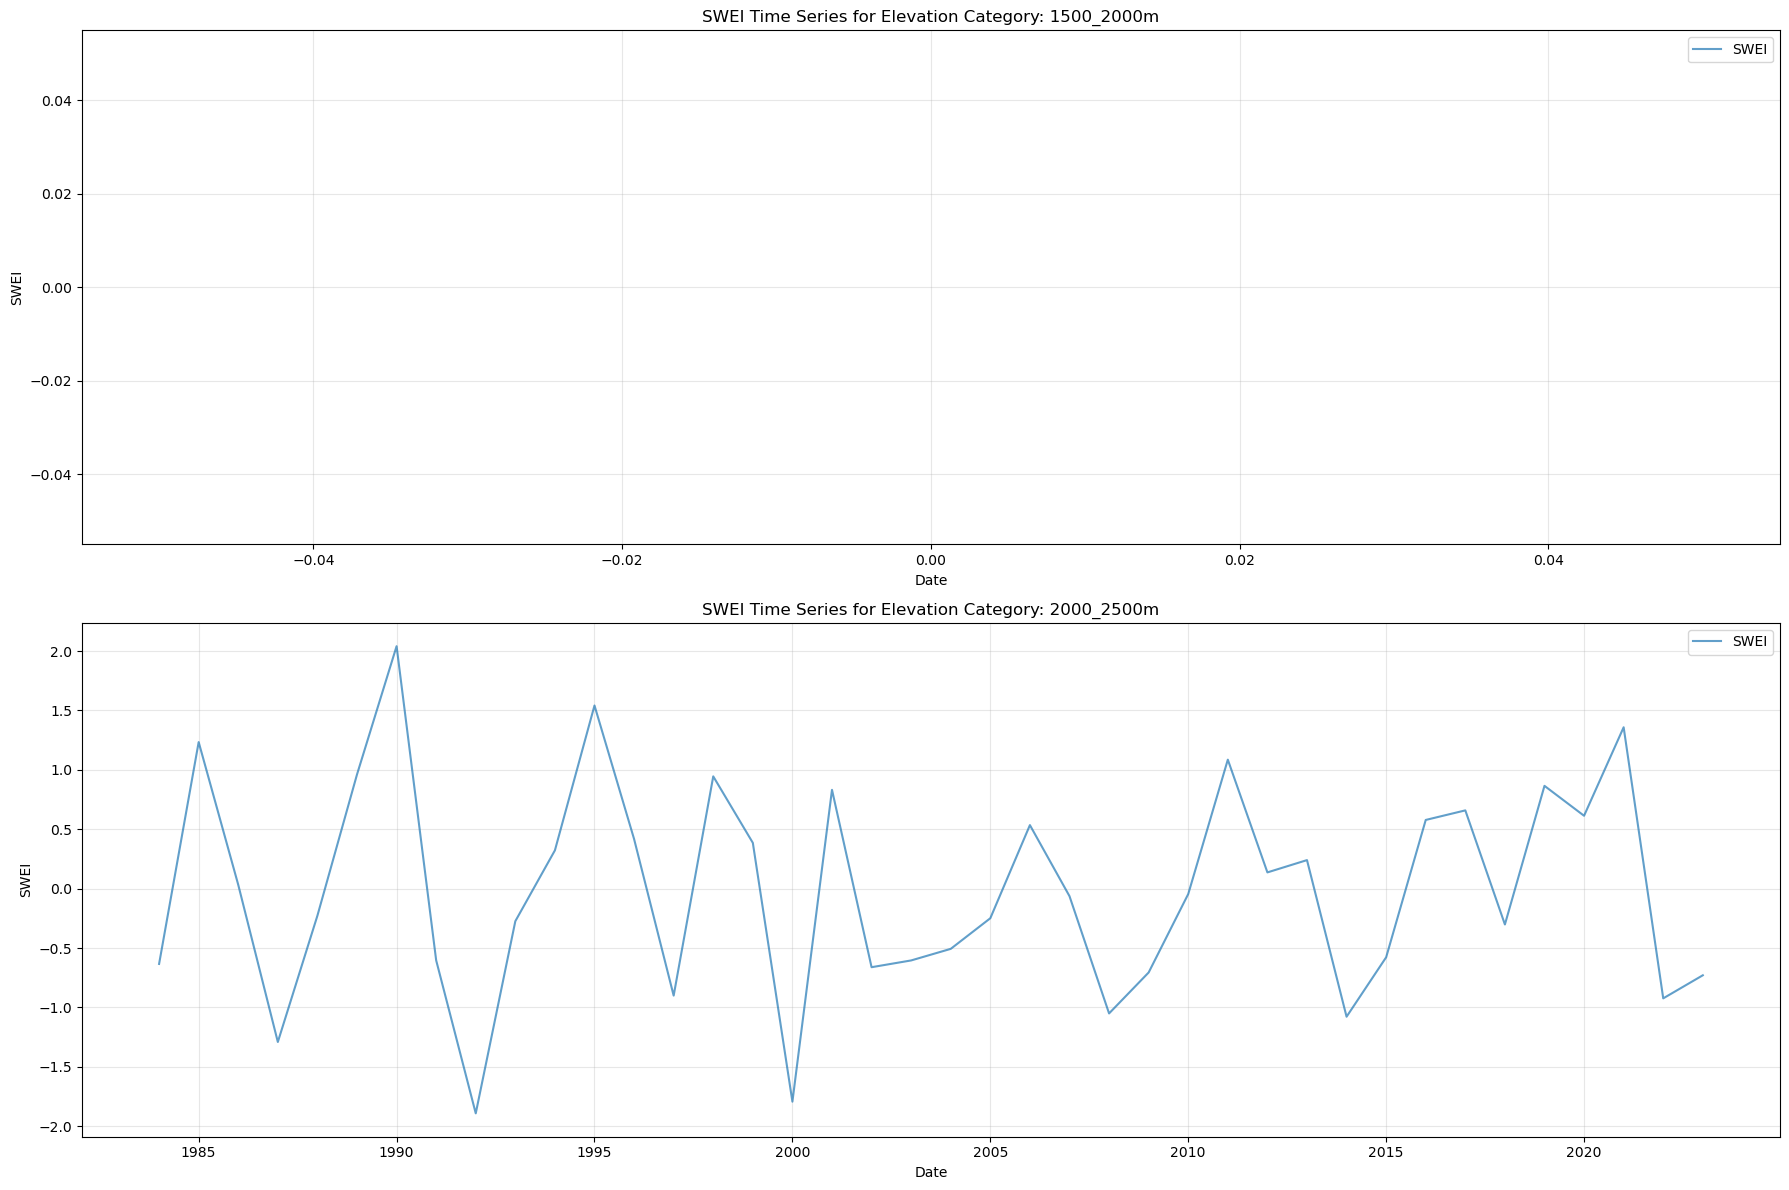

In [26]:
# plot SWEI time series for each elevation category
elev_categories = ['1500_2000m', '2000_2500m']
plt.figure(figsize=(18, 12))    
for i, elev_cat in enumerate(elev_categories, 1):
    plt.subplot(len(elev_categories), 1, i)

    # Filter data for the current elevation category and sort by time
    df_cat = sswei_monthly_avg.loc[sswei_monthly_avg['Elevation_Category'] == elev_cat].sort_values('Seasonal_Year')

    # Plot SWEI (x and y have matching lengths)
    plt.plot(
        df_cat['Seasonal_Year'],
        df_cat['Avg_SWEI_8mo'],
        label='SWEI',
        color='tab:blue',
        alpha=0.7
    )

    plt.title(f'SWEI Time Series for Elevation Category: {elev_cat}')
    plt.xlabel('Date')
    plt.ylabel('SWEI')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# CaSR SWEI

1-Month SWEI

In [62]:
# 1-month SWEI
swei_1mo = compute_swei(casr_data, window_months=1)
#swei_1mo_output_dir = config['SWEI_output_dir'] 
#swei_1mo_output_dir.mkdir(parents=True, exist_ok=True)
#swei_1mo.to_csv(swei_1mo_output_dir / 'bow_casr_swei_1mo.csv', index=False)

display(swei_1mo.head())

,station_id,time,SWE_monthly,Seasonal_Year,SWE_1mo,month,Gringorten_p,SWEI,lon,lat,Elevation_Category
0,1,1980-10-01,206.20874,1980,206.20874,10,0.262013,-0.637153,-116.138,51.3346,2000_2500m
1,1,1980-11-01,1297.43750,1980,1297.43750,11,0.511333,0.028411,-116.138,51.3346,2000_2500m
2,1,1980-12-01,3418.97217,1980,3418.97217,12,0.873980,1.145409,-116.138,51.3346,2000_2500m
3,1,1981-01-01,4229.06250,1980,4229.06250,1,0.647325,0.378110,-116.138,51.3346,2000_2500m
4,1,1981-02-01,4490.93750,1980,4490.93750,2,0.443336,-0.142516,-116.138,51.3346,2000_2500m


In [63]:
# avaerage SWEI over the Elevation categories, month and seasonal year
swei_1mo_avg = (
    swei_1mo
    .groupby(
        ['Elevation_Category', 'Seasonal_Year', 'month'],
        as_index=False
    )
    .agg(
        Avg_SWEI_1mo=('SWEI', 'mean')
    )
)

display(swei_1mo_avg)

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_1mo
0,1000_1500m,1980,1,-1.573456
1,1000_1500m,1980,2,-0.754661
2,1000_1500m,1980,3,-1.294272
3,1000_1500m,1980,4,-0.979583
4,1000_1500m,1980,5,1.227319
...,...,...,...,...
1403,500_1000m,2023,4,0.266537
1404,500_1000m,2023,5,0.536958
1405,500_1000m,2023,10,1.030850
1406,500_1000m,2023,11,-0.990671


In [ ]:
# Plot monthly SSWEI on bow basin subplots

# Desired month order: October (10) to May (5)
month_order = [10, 11, 12, 1, 2, 3, 4, 5]
# Keep only months that actually exist in the data, in the desired order
available_months = swei_1mo_2023['month'].unique().tolist()
months = [m for m in month_order if m in available_months]

n_months = len(months)

# Create subplot grid (2 rows x 4 columns for up to 8 months)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Define a color map for drought severity (keys match classify_sswei output)
severity_colors_SWEI = {
    'Exceptional Drought': '#800026',
    'Extreme Drought': '#BD0026',
    'Severe Drought': '#E31A1C',
    'Moderate Dry': '#FD8D3C',
    'Abnaormally Dry': '#FED976',
    'Near Normal': '#FFFFCC',
    'Abnormally Wet': '#C7E9B4',
    'Moderate Wet': '#7FCDBB',
    'Severe Wet': '#41B6C4',
    'Extreme Wet': '#225EA8',
    'Extremely Wet': '#0C2C84',
    'No Data': '#dddddd'
}

# Create a classification function for SSWEI values
# (same thresholds as before)
def classify_sswei(value):
    if pd.isna(value):
        return 'No Data'
    elif value <= -2.0:
        return 'Exceptional Drought'
    elif value < -1.6:
        return 'Extreme Drought'
    elif value < -1.3:
        return 'Severe Drought'
    elif value < -0.8:
        return 'Moderate Dry'
    elif value < -0.5:
        return 'Abnaormally Dry'
    elif value < 0.5:
        return 'Near Normal'
    elif value < 0.8:
        return 'Abnormally Wet'
    elif value < 1.3:
        return 'Moderate Wet'
    elif value < 1.6:
        return 'Severe Wet'
    elif value < 2.0:
        return 'Extreme Wet'
    else:
        return 'Extremely Wet'

# Initialize color column (will be updated per month in the loop)
bow_basin['color'] = '#dddddd'

# Month names for titles
month_names = {10: 'October', 11: 'November', 12: 'December',
               1: 'January', 2: 'February', 3: 'March',
               4: 'April', 5: 'May'}

# Plot each month
for season_year in range(1980, 2024):
    # SSWEI data for this season
    swei_year = swei_1mo_avg[swei_1mo_avg['Seasonal_Year'] == season_year]

    # Months available for this season, in desired order
    available_months = swei_year['month'].unique().tolist()
    months_year = [m for m in month_order if m in available_months]
    n_months_year = len(months_year)

    # Create subplot grid (2 rows x 4 columns for up to 8 months)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for idx, month in enumerate(months_year):
        ax = axes[idx]

        # Subset SSWEI for this month and season
        month_data = swei_year[swei_year['month'] == month].copy()

        # One row per elevation band; just select and rename
        month_data_long = month_data[['Elevation_Category', 'Avg_SWEI_1mo']].copy()
        month_data_long = month_data_long.rename(columns={'Avg_SWEI_1mo': 'SSWEI'})

        # Merge SSWEI values with basin geometry using elevation categories
        basin_plot = bow_basin.merge(
            month_data_long[['Elevation_Category', 'SSWEI']],
            left_on='elev_class',
            right_on='Elevation_Category',
            how='left'
        )

        # Classify SSWEI values and assign colors
        basin_plot['Drought_Classification'] = basin_plot['SSWEI'].apply(classify_sswei)
        basin_plot['color'] = basin_plot['Drought_Classification'].map(severity_colors_SWEI).fillna('#dddddd')

        # Plot the basin with SSWEI values
        basin_plot.plot(ax=ax, color=basin_plot['color'], edgecolor='black', linewidth=0.5)

        # Calendar year for the given month in this snow season
        display_year = season_year if month >= 10 else season_year + 1
        ax.set_title(f"{month_names.get(month, str(month))} {display_year}",
                     fontsize=12, fontweight='bold')
        ax.axis('off')

    # Hide any unused subplots (if fewer than 8 months)
    for j in range(n_months_year, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Monthly SSWEI Distribution across Bow River Basin (Season {season_year})',
                 fontsize=16, fontweight='bold', y=0.98)

    plt.legend(handles=[mpatches.Patch(color=color, label=label)
                        for label, color in severity_colors_SWEI.items()],
               bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0., title='Drought Severity')
    plt.tight_layout()

    # Save figure for this season
    #out_file_map = config['SWEI_plots'] / f'SSWEI_bow_basin_monthly_{season_year}.png'
    #fig.savefig(out_file_map, dpi=300, bbox_inches='tight')
   # plt.show()

3 - Month SWEI

In [64]:
# 3-month SWEI
swei_3mo = compute_swei(casr_data, window_months=3)
swei_3mo_output_dir = config['SWEI_output_dir'] 
swei_3mo_output_dir.mkdir(parents=True, exist_ok=True)
swei_3mo.to_csv(swei_3mo_output_dir / 'bow_casr_swei_3mo.csv', index=False)

display(swei_3mo)

,station_id,time,SWE_monthly,Seasonal_Year,SWE_3mo,month,Gringorten_p,SWEI,lon,lat,Elevation_Category
2,1,1980-12-01,3418.972170,1980,4922.618410,12,0.737987,0.637153,-116.1380,51.3346,2000_2500m
3,1,1981-01-01,4229.062500,1980,8945.472170,1,0.715322,0.569000,-116.1380,51.3346,2000_2500m
4,1,1981-02-01,4490.937500,1980,12138.972170,2,0.647325,0.378110,-116.1380,51.3346,2000_2500m
5,1,1981-03-01,5416.625000,1980,14136.625000,3,0.466002,-0.085324,-116.1380,51.3346,2000_2500m
6,1,1981-04-01,6174.931640,1980,16082.494140,4,0.443336,-0.142516,-116.1380,51.3346,2000_2500m
...,...,...,...,...,...,...,...,...,...,...,...
90459,257,2024-01-01,188.628906,2023,215.202453,1,0.171351,-0.948841,-111.6202,50.0960,500_1000m
90460,257,2024-02-01,147.339844,2023,351.277984,2,0.375340,-0.317743,-111.6202,50.0960,500_1000m
90461,257,2024-03-01,228.636963,2023,564.605712,3,0.579329,0.200177,-111.6202,50.0960,500_1000m
90462,257,2024-04-01,33.114258,2023,409.091064,4,0.715322,0.569000,-111.6202,50.0960,500_1000m


In [65]:
# avaerage SWEI over the Elevation categories, month and seasonal year
swei_3mo_avg = (
    swei_3mo
    .groupby(
        ['Elevation_Category', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SWEI_3mo=('SWEI', 'mean')
    )
)

display(swei_3mo_avg.head(15))

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_3mo
0,1000_1500m,1980,1,-0.002038
1,1000_1500m,1980,2,-0.254388
2,1000_1500m,1980,3,-2.022103
3,1000_1500m,1980,4,-1.538498
4,1000_1500m,1980,5,-1.075890
5,1000_1500m,1980,12,0.403853
6,1000_1500m,1981,1,-0.255568
7,1000_1500m,1981,2,0.421963
8,1000_1500m,1981,3,0.707197
9,1000_1500m,1981,4,0.858082


In [ ]:
# Plot each month
for season_year in range(1980, 2024):
    # SSWEI data for this season
    swei_year = swei_3mo_avg[swei_3mo_avg['Seasonal_Year'] == season_year]

    # Months available for this season, in desired order
    available_months = swei_year['month'].unique().tolist()
    months_year = [m for m in month_order if m in available_months]
    n_months_year = len(months_year)

    # Create subplot grid (2 rows x 3 columns for up to 6 months)
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes = axes.flatten()

    for idx, month in enumerate(months_year):
        ax = axes[idx]

        # Subset SSWEI for this month and season
        month_data = swei_year[swei_year['month'] == month].copy()

        # One row per elevation band; just select and rename
        month_data_long = month_data[['Elevation_Category', 'Avg_SWEI_3mo']].copy()
        month_data_long = month_data_long.rename(columns={'Avg_SWEI_3mo': 'SSWEI'})

        # Merge SSWEI values with basin geometry using elevation categories
        basin_plot = bow_basin.merge(
            month_data_long[['Elevation_Category', 'SSWEI']],
            left_on='elev_class',
            right_on='Elevation_Category',
            how='left'
        )

        # Classify SSWEI values and assign colors
        basin_plot['Drought_Classification'] = basin_plot['SSWEI'].apply(classify_sswei)
        basin_plot['color'] = basin_plot['Drought_Classification'].map(severity_colors_SWEI).fillna('#dddddd')

        # Plot the basin with SSWEI values
        basin_plot.plot(ax=ax, color=basin_plot['color'], edgecolor='black', linewidth=0.5)

        # Calendar year for the given month in this snow season
        display_year = season_year if month >= 10 else season_year + 1
        ax.set_title(f"{month_names.get(month, str(month))} {display_year}",
                     fontsize=12, fontweight='bold')
        ax.axis('off')

    # Hide any unused subplots (if fewer than 8 months)
    for j in range(n_months_year, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'3-month SSWEI Distribution across Bow River Basin (Season {season_year})',
                 fontsize=16, fontweight='bold', y=0.98)

    plt.legend(handles=[mpatches.Patch(color=color, label=label)
                        for label, color in severity_colors_SWEI.items()],
               bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0., title='Drought Severity')
    plt.tight_layout()

    # Save figure for this season
    #out_file_map = config['SWEI_plots'] / f'SSWEI_bow_basin_monthly_{season_year}.png'
    #fig.savefig(out_file_map, dpi=300, bbox_inches='tight')
   # plt.show()

Seasonal SWEI - 8 months

In [66]:
# 8-month SWEI
swei_8mo = compute_swei(casr_data, window_months=8)
swei_8mo_output_dir = config['SWEI_output_dir'] 
swei_8mo_output_dir.mkdir(parents=True, exist_ok=True)
swei_8mo.to_csv(swei_8mo_output_dir / 'bow_casr_swei_8mo.csv', index=False)

display(swei_8mo)

,station_id,time,SWE_monthly,Seasonal_Year,SWE_8mo,month,Gringorten_p,SWEI,lon,lat,Elevation_Category
7,1,1981-05-01,5072.800764,1980,30306.975814,5,0.556664,0.142516,-116.1380,51.3346,2000_2500m
15,1,1982-05-01,7276.954120,1981,34493.079364,5,0.737987,0.637153,-116.1380,51.3346,2000_2500m
23,1,1983-05-01,5607.820307,1982,34208.649527,5,0.692656,0.503394,-116.1380,51.3346,2000_2500m
31,1,1984-05-01,5777.537110,1983,28006.298830,5,0.420671,-0.200177,-116.1380,51.3346,2000_2500m
39,1,1985-05-01,4583.076164,1984,26935.667961,5,0.352675,-0.378110,-116.1380,51.3346,2000_2500m
...,...,...,...,...,...,...,...,...,...,...,...
90431,257,2020-05-01,0.000000,2019,584.591553,5,0.284678,-0.569000,-111.6202,50.0960,500_1000m
90439,257,2021-05-01,11.372070,2020,579.107177,5,0.239347,-0.708404,-111.6202,50.0960,500_1000m
90447,257,2022-05-01,0.000000,2021,283.044342,5,0.012693,-2.235488,-111.6202,50.0960,500_1000m
90455,257,2023-05-01,0.000000,2022,743.058776,5,0.466002,-0.085324,-111.6202,50.0960,500_1000m


In [67]:
# avaerage SWEI over the Elevation categories, month and seasonal year
swei_8mo_avg = (
    swei_8mo
    .groupby(
        ['Elevation_Category', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SWEI_8mo=('SWEI', 'mean')
    )
)

display(swei_8mo_avg.head(15))

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_8mo
0,1000_1500m,1980,5,-0.778473
1,1000_1500m,1981,5,0.320094
2,1000_1500m,1982,5,-0.942805
3,1000_1500m,1983,5,-0.356098
4,1000_1500m,1984,5,-0.147442
5,1000_1500m,1985,5,0.314323
6,1000_1500m,1986,5,-0.474813
7,1000_1500m,1987,5,-1.338402
8,1000_1500m,1988,5,0.898300
9,1000_1500m,1989,5,0.113604


In [68]:
#print snow drought years for each elevation category
for elev_cat in swei_8mo_avg['Elevation_Category'].unique():
    elev_data = swei_8mo_avg[swei_8mo_avg['Elevation_Category'] == elev_cat]
    drought_years = elev_data[elev_data['Avg_SWEI_8mo'] <= -0.5]['Seasonal_Year'].unique()
    print(f"Elevation Category: {elev_cat}, Drought Years (Avg SWEI <= -0.5): {drought_years.tolist()}")

Elevation Category: 1000_1500m, Drought Years (Avg SWEI <= -0.5): [1980, 1982, 1987, 1991, 1993, 1994, 1998, 2000, 2004, 2005, 2007, 2011, 2015]
Elevation Category: 1500_2000m, Drought Years (Avg SWEI <= -0.5): [1980, 1991, 1993, 1994, 1998, 2000, 2002, 2004, 2005, 2006, 2007, 2011, 2015]
Elevation Category: 2000_2500m, Drought Years (Avg SWEI <= -0.5): [1987, 1996, 1997, 1998, 2000, 2002, 2004, 2005, 2009, 2011, 2015]
Elevation Category: 500_1000m, Drought Years (Avg SWEI <= -0.5): [1994, 1997, 1998, 2000, 2004, 2005, 2006, 2011, 2015, 2016, 2018, 2021, 2023]


In [ ]:
# Plot each month
for season_year in range(1980, 2024):
    # SSWEI data for this season
    swei_year = swei_8mo_avg[swei_8mo_avg['Seasonal_Year'] == season_year]

    # Months available for this season, in desired order
    available_months = swei_year['month'].unique().tolist()
    months_year = [m for m in month_order if m in available_months]
    n_months_year = len(months_year)

    # Create subplot grid (1 rows x 1 columns for up to 6 months)
    fig, axes = plt.subplots(1, 1, figsize=(20, 10))
    axes = np.atleast_1d(axes).ravel()

    for idx, month in enumerate(months_year):
        ax = axes[idx]

        # Subset SSWEI for this month and season
        month_data = swei_year[swei_year['month'] == month].copy()

        # One row per elevation band; just select and rename
        month_data_long = month_data[['Elevation_Category', 'Avg_SWEI_8mo']].copy()
        month_data_long = month_data_long.rename(columns={'Avg_SWEI_8mo': 'SSWEI'})

        # Merge SSWEI values with basin geometry using elevation categories
        basin_plot = bow_basin.merge(
            month_data_long[['Elevation_Category', 'SSWEI']],
            left_on='elev_class',
            right_on='Elevation_Category',
            how='left'
        )

        # Classify SSWEI values and assign colors
        basin_plot['Drought_Classification'] = basin_plot['SSWEI'].apply(classify_sswei)
        basin_plot['color'] = basin_plot['Drought_Classification'].map(severity_colors_SWEI).fillna('#dddddd')

        # Plot the basin with SSWEI values
        basin_plot.plot(ax=ax, color=basin_plot['color'], edgecolor='black', linewidth=0.5)

        # Calendar year for the given month in this snow season
        #display_year = season_year if month >= 10 else season_year + 1
        #ax.set_title(f"{month_names.get(month, str(month))} {display_year}",
        #             fontsize=12, fontweight='bold')
        ax.axis('off')

    # Hide any unused subplots (if fewer than 8 months)
    for j in range(n_months_year, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'8-month SSWEI Distribution across Bow River Basin (Season {season_year})',
                 fontsize=16, fontweight='bold', y=0.98)

    plt.legend(handles=[mpatches.Patch(color=color, label=label)
                        for label, color in severity_colors_SWEI.items()],
               bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0., title='Drought Severity')
    plt.tight_layout()

    # Save figure for this season
    #out_file_map = config['SWEI_plots'] / f'SSWEI_bow_basin_8month_{season_year}.png'
    #fig.savefig(out_file_map, dpi=300, bbox_inches='tight')
   # plt.show()

# SPI Calculations

In [69]:
# load percipitation data and compute SPI 
precip_data = casr_data[['time', 'station_id','lon', 'lat', 'Precipitation', 'Elevation_Category']].copy()
precip_data['time'] = pd.to_datetime(precip_data['time'])
precip_data['month'] = precip_data['time'].dt.month
display(precip_data.head())

,time,station_id,lon,lat,Precipitation,Elevation_Category,month
0,1980-10-10,1,-116.1380,51.3346,0.009879,2000_2500m,10
2,1983-10-12,2,-116.1875,51.4191,0.023846,2000_2500m,10
3,1980-12-11,2,-116.1875,51.4191,4.578907,2000_2500m,12
5,1982-10-29,2,-116.1875,51.4191,1.777088,2000_2500m,10
6,1982-01-18,2,-116.1875,51.4191,1.890419,2000_2500m,1


Functions

In [72]:
def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id", "lon", "lat", "Elevation_Category"]]
        .drop_duplicates("station_id")
        .set_index("station_id")
    )


def daily_to_monthly_precipitation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Daily precipitation → monthly integrated precipitation.
    Seasonal_Year is recomputed from time.
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    monthly = (
        out
        .groupby(
            ["station_id", pd.Grouper(key="time", freq="MS")],
            as_index=False
        )
        .agg(
            Precipitation_monthly=("Precipitation", "sum")
        )
    )

    # Recompute Seasonal_Year (e.g., Oct–Sep water year)
    monthly["Seasonal_Year"] = np.where(
        monthly["time"].dt.month >= 10,
        monthly["time"].dt.year,
        monthly["time"].dt.year - 1
    )

    return monthly



def rolling_integrated_precipitation_by_season(
    monthly_df: pd.DataFrame,
    window_months: int
) -> pd.DataFrame:
    """
    Compute rolling k‑month integrated precipitation within each Seasonal_Year.

    • Rolling windows do NOT cross Seasonal_Year boundaries.
    • First (k‑1) months of each season are dropped.
    • Works for any window (3, 6, 8, …).
    """

    out = monthly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"Precipitation_{window_months}mo"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["Precipitation_monthly"]
        .rolling(window=window_months, min_periods=window_months)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"Precipitation_{window_months}mo"])


def calculate_spi(series: pd.Series, min_samples: int = 20) -> pd.Series:
    """
    Calculates SPI using a mixed Gamma distribution.
    """
    x = series.values

    # Probability of zero precipitation
    q = np.mean(x == 0)

    pos = x[x > 0]
    if len(pos) < min_samples:
        return pd.Series(np.nan, index=series.index)

    shape, loc, scale = gamma.fit(pos, floc=0)
    
    G = gamma.cdf(x, shape, loc=loc, scale=scale)
    H = q + (1 - q) * G

    H = np.clip(H, 1e-6, 1 - 1e-6)

    spi = norm.ppf(H)

    return pd.Series(spi, index=series.index)



def compute_spi_for_grids(
    precip_df: pd.DataFrame,
    precip_col: str
) -> pd.DataFrame:

    out = []

    for station_id, gdf in precip_df.groupby("station_id"):
        gdf = gdf.sort_values("time")

        for month in range(1, 13):
            mask = gdf["time"].dt.month == month
            spi_series = calculate_spi(gdf.loc[mask, precip_col])

            gdf.loc[mask, "SPI"] = spi_series

        gdf["station_id"] = station_id
        out.append(gdf)

    return pd.concat(out).sort_values(["station_id", "time"])


def spi_pipeline(
    daily_df: pd.DataFrame,
    window_months: int
) -> pd.DataFrame:

    # 1. Metadata
    grid_meta = extract_grid_metadata(daily_df)

    # 2. Daily → Monthly
    monthly = daily_to_monthly_precipitation(daily_df)

    # 3. Rolling integrated precipitation
    rolled = rolling_integrated_precipitation_by_season(
        monthly,
        window_months=window_months
    )

    precip_col = f"Precipitation_{window_months}mo"

    # 4. SPI calculation
    spi = compute_spi_for_grids(rolled, precip_col)

    # 5. Join metadata
    final = (
        spi
        .merge(grid_meta, left_on="station_id", right_index=True, how="left")
        .sort_values(["station_id", "time"])
    )
    final["month"] = final["time"].dt.month.astype("int32")

    return final

def classify_spi(spi):

    if spi <= -2.0:
        return "Extremely dry"
    elif spi <= -1.5:
        return "Severely dry"
    elif spi <= -1.0:
        return "Moderately dry"
    elif spi < 1.0:
        return "Near normal"
    elif spi < 1.5:
        return "Moderately wet"
    elif spi < 2.0:
        return "Severely wet"
    else:
        return "Extremely wet"

severity_colors_SPI = {
        'Extremely dry': '#800026',
        'Severely dry': '#E31A1C',
        'Moderately dry': '#FD8D3C',
        'Abnormally dry': '#FED976',
        'Near normal': '#FFFFCC',
        'Moderately wet': '#7FCDBB',
        'Severely wet': '#41B6C4',
        'Extremely wet': '#0C2C84',
        'No Data': '#dddddd'
}


In [73]:
# Compute SPI for 1-month, 3-month, and 8-month windows
spi_1  = spi_pipeline(precip_data, window_months=1)
spi_3  = spi_pipeline(precip_data, window_months=3)
spi_8  = spi_pipeline(precip_data, window_months=8)

# Save SPI results
spi_output_dir = config['SPI_output_dir']
spi_output_dir.mkdir(parents=True, exist_ok=True)
spi_1.to_csv(spi_output_dir / 'bow_casr_spi_1mo.csv', index=False)
spi_3.to_csv(spi_output_dir / 'bow_casr_spi_3mo.csv', index=False)
spi_8.to_csv(spi_output_dir / 'bow_casr_spi_8mo.csv', index=False)

display(spi_1.head())
display(spi_3.head())
display(spi_8.head())

c:\Users\walimunige.rupasingh\AppData\Local\miniconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\walimunige.rupasingh\AppData\Local\miniconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\walimunige.rupasingh\AppData\Local\miniconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\walimunige.rupasingh\AppData\Local\miniconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\walimunige.rupasingh\AppData\Local\miniconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\walimunige.rupasin

,station_id,time,Precipitation_monthly,Seasonal_Year,Precipitation_1mo,SPI,lon,lat,Elevation_Category,month
0,1,1980-10-01,15.461886,1980,15.461886,-1.719195,-116.138,51.3346,2000_2500m,10
1,1,1980-11-01,50.295086,1980,50.295086,-0.009426,-116.138,51.3346,2000_2500m,11
2,1,1980-12-01,108.955549,1980,108.955549,2.376207,-116.138,51.3346,2000_2500m,12
3,1,1981-01-01,13.916898,1980,13.916898,-1.677507,-116.138,51.3346,2000_2500m,1
4,1,1981-02-01,38.431036,1980,38.431036,0.397935,-116.138,51.3346,2000_2500m,2


,station_id,time,Precipitation_monthly,Seasonal_Year,Precipitation_3mo,SPI,lon,lat,Elevation_Category,month
2,1,1980-12-01,108.955549,1980,174.712521,0.552701,-116.138,51.3346,2000_2500m,12
3,1,1981-01-01,13.916898,1980,173.167533,0.667088,-116.138,51.3346,2000_2500m,1
4,1,1981-02-01,38.431036,1980,161.303483,1.010372,-116.138,51.3346,2000_2500m,2
5,1,1981-03-01,18.109773,1980,70.457707,-1.433520,-116.138,51.3346,2000_2500m,3
6,1,1981-04-01,36.249706,1980,92.790515,-0.500582,-116.138,51.3346,2000_2500m,4


,station_id,time,Precipitation_monthly,Seasonal_Year,Precipitation_8mo,SPI,lon,lat,Elevation_Category,month
7,1,1981-05-01,49.272601,1980,330.692535,-0.401809,-116.138,51.3346,2000_2500m,5
15,1,1982-05-01,24.854834,1981,321.687604,-0.531544,-116.138,51.3346,2000_2500m,5
23,1,1983-05-01,25.470663,1982,231.587842,-1.990738,-116.138,51.3346,2000_2500m,5
31,1,1984-05-01,67.581612,1983,272.967472,-1.279772,-116.138,51.3346,2000_2500m,5
39,1,1985-05-01,44.867321,1984,258.220625,-1.524064,-116.138,51.3346,2000_2500m,5


In [74]:
# avaerage monthly SWEI over the Elevation categories, month and seasonal year
spi_1mo_avg = (
    spi_1
    .groupby(
        ['Elevation_Category', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SPI_1mo=('SPI', 'mean')
    )
)

display(spi_1mo_avg.head(15))

# avaerage 3-month SWEI over the Elevation categories, month and seasonal year
spi_3mo_avg = (
    spi_3
    .groupby(
        ['Elevation_Category', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SPI_3mo=('SPI', 'mean')
    )
)

display(spi_3mo_avg.head(15))

# avaerage 8-month SWEI over the Elevation categories, month and seasonal year
spi_8mo_avg = (
    spi_8
    .groupby(
        ['Elevation_Category', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SPI_8mo=('SPI', 'mean')
    )
)

display(spi_8mo_avg.head(15))

,Elevation_Category,Seasonal_Year,month,Avg_SPI_1mo
0,1000_1500m,1980,1,-0.531992
1,1000_1500m,1980,2,-0.401957
2,1000_1500m,1980,3,-0.362227
3,1000_1500m,1980,4,-1.590163
4,1000_1500m,1980,5,1.654832
5,1000_1500m,1980,10,0.299526
6,1000_1500m,1980,11,0.591521
7,1000_1500m,1980,12,0.968124
8,1000_1500m,1981,1,0.395596
9,1000_1500m,1981,2,-0.277067


,Elevation_Category,Seasonal_Year,month,Avg_SPI_3mo
0,1000_1500m,1980,1,0.553736
1,1000_1500m,1980,2,0.023588
2,1000_1500m,1980,3,-0.885963
3,1000_1500m,1980,4,-1.497750
4,1000_1500m,1980,5,0.928880
5,1000_1500m,1980,12,0.785769
6,1000_1500m,1981,1,-1.418948
7,1000_1500m,1981,2,-0.913146
8,1000_1500m,1981,3,0.403401
9,1000_1500m,1981,4,-0.291803


,Elevation_Category,Seasonal_Year,month,Avg_SPI_8mo
0,1000_1500m,1980,5,0.813369
1,1000_1500m,1981,5,-0.395595
2,1000_1500m,1982,5,-0.728869
3,1000_1500m,1983,5,-1.105589
4,1000_1500m,1984,5,-1.615920
5,1000_1500m,1985,5,-0.524282
6,1000_1500m,1986,5,-2.081561
7,1000_1500m,1987,5,-2.430226
8,1000_1500m,1988,5,-0.779130
9,1000_1500m,1989,5,0.643315


In [ ]:
# Plot monthly SPI on bow basin subplots

# Desired month order: October (10) to May (5)
month_order = [10, 11, 12, 1, 2, 3, 4, 5]
# Keep only months that actually exist in the data, in the desired order
available_months = spi_1mo_avg['month'].unique().tolist()
months = [m for m in month_order if m in available_months]

n_months = len(months)

# Create subplot grid (2 rows x 4 columns for up to 8 months)
#fig, axes = plt.subplots(2, 4, figsize=(20, 10))
#axes = axes.flatten()


# Initialize color column (will be updated per month in the loop)
bow_basin['color'] = '#dddddd'

# Month names for titles
month_names = {10: 'October', 11: 'November', 12: 'December',
               1: 'January', 2: 'February', 3: 'March',
               4: 'April', 5: 'May'}

# Plot each month
for season_year in range(1980, 2024):
    # SPI data for this season
    spi_year = spi_1mo_avg[spi_1mo_avg['Seasonal_Year'] == season_year]

    # Months available for this season, in desired order
    available_months = spi_year['month'].unique().tolist()
    months_year = [m for m in month_order if m in available_months]
    n_months_year = len(months_year)

    # Create subplot grid (2 rows x 4 columns for up to 8 months)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for idx, month in enumerate(months_year):
        ax = axes[idx]

        # Subset SPI for this month and season
        month_data = spi_year[spi_year['month'] == month].copy()

        # One row per elevation band; just select and rename
        month_data_long = month_data[['Elevation_Category', 'Avg_SPI_1mo']].copy()
        month_data_long = month_data_long.rename(columns={'Avg_SPI_1mo': 'SPI'})

        # Merge SPI values with basin geometry using elevation categories
        basin_plot = bow_basin.merge(
            month_data_long[['Elevation_Category', 'SPI']],
            left_on='elev_class',
            right_on='Elevation_Category',
            how='left'
        )

        # Classify SPI values and assign colors
        basin_plot['Drought_Classification'] = basin_plot['SPI'].apply(classify_spi)
        basin_plot['color'] = basin_plot['Drought_Classification'].map(severity_colors_SPI).fillna('#dddddd')

        # Plot the basin with SPI values
        basin_plot.plot(ax=ax, color=basin_plot['color'], edgecolor='black', linewidth=0.5)

        # Calendar year for the given month in this snow season
        display_year = season_year if month >= 10 else season_year + 1
        ax.set_title(f"{month_names.get(month, str(month))} {display_year}",
                     fontsize=12, fontweight='bold')
        ax.axis('off')

    # Hide any unused subplots (if fewer than 8 months)
    for j in range(n_months_year, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Monthly SPI Distribution across Bow River Basin (Season {season_year})',
                 fontsize=16, fontweight='bold', y=0.98)

    plt.legend(handles=[mpatches.Patch(color=color, label=label)
                        for label, color in severity_colors_SPI.items()],
               bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0., title='Drought Severity')
    plt.tight_layout()

    # Save figure for this season
    out_file_map = config['SPI_plots'] / f'SPI_bow_basin_monthly_{season_year}.png'
    fig.savefig(out_file_map, dpi=300, bbox_inches='tight')
   # plt.show()

In [ ]:
# Plot for season
for season_year in range(1980, 2024):
    # SSWEI data for this season
    spi_year = spi_8mo_avg[spi_8mo_avg['Seasonal_Year'] == season_year]

    # Months available for this season, in desired order
    available_months = spi_year['month'].unique().tolist()
    months_year = [m for m in month_order if m in available_months]
    n_months_year = len(months_year)

    # Create subplot grid (1 rows x 1 columns for up to 6 months)
    fig, axes = plt.subplots(1, 1, figsize=(20, 10))
    axes = np.atleast_1d(axes).ravel()

    for idx, month in enumerate(months_year):
        ax = axes[idx]

        # Subset SSWEI for this month and season
        month_data = spi_year[spi_year['month'] == month].copy()

        # One row per elevation band; just select and rename
        month_data_long = month_data[['Elevation_Category', 'Avg_SPI_8mo']].copy()
        month_data_long = month_data_long.rename(columns={'Avg_SPI_8mo': 'SPI'})

        # Merge SSWEI values with basin geometry using elevation categories
        basin_plot = bow_basin.merge(
            month_data_long[['Elevation_Category', 'SPI']],
            left_on='elev_class',
            right_on='Elevation_Category',
            how='left'
        )

        # Classify SSWEI values and assign colors
        basin_plot['Drought_Classification'] = basin_plot['SPI'].apply(classify_spi)
        basin_plot['color'] = basin_plot['Drought_Classification'].map(severity_colors_SPI).fillna('#dddddd')

        # Plot the basin with SPI values
        basin_plot.plot(ax=ax, color=basin_plot['color'], edgecolor='black', linewidth=0.5)

        # Calendar year for the given month in this snow season
        #display_year = season_year if month >= 10 else season_year + 1
        #ax.set_title(f"{month_names.get(month, str(month))} {display_year}",
        #             fontsize=12, fontweight='bold')
        ax.axis('off')

    # Hide any unused subplots (if fewer than 8 months)
    for j in range(n_months_year, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'8-month SPI Distribution across Bow River Basin (Season {season_year})',
                 fontsize=16, fontweight='bold', y=0.98)

    plt.legend(handles=[mpatches.Patch(color=color, label=label)
                        for label, color in severity_colors_SPI.items()],
               bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0., title='Drought Severity')
    plt.tight_layout()

    # Save figure for this season
    out_file_map = config['SPI_plots'] / f'SPI_bow_basin_8month_{season_year}.png'
    fig.savefig(out_file_map, dpi=300, bbox_inches='tight')
   # plt.show()

# Heatmap - SPI & SWEI

C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_33244\1210320836.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


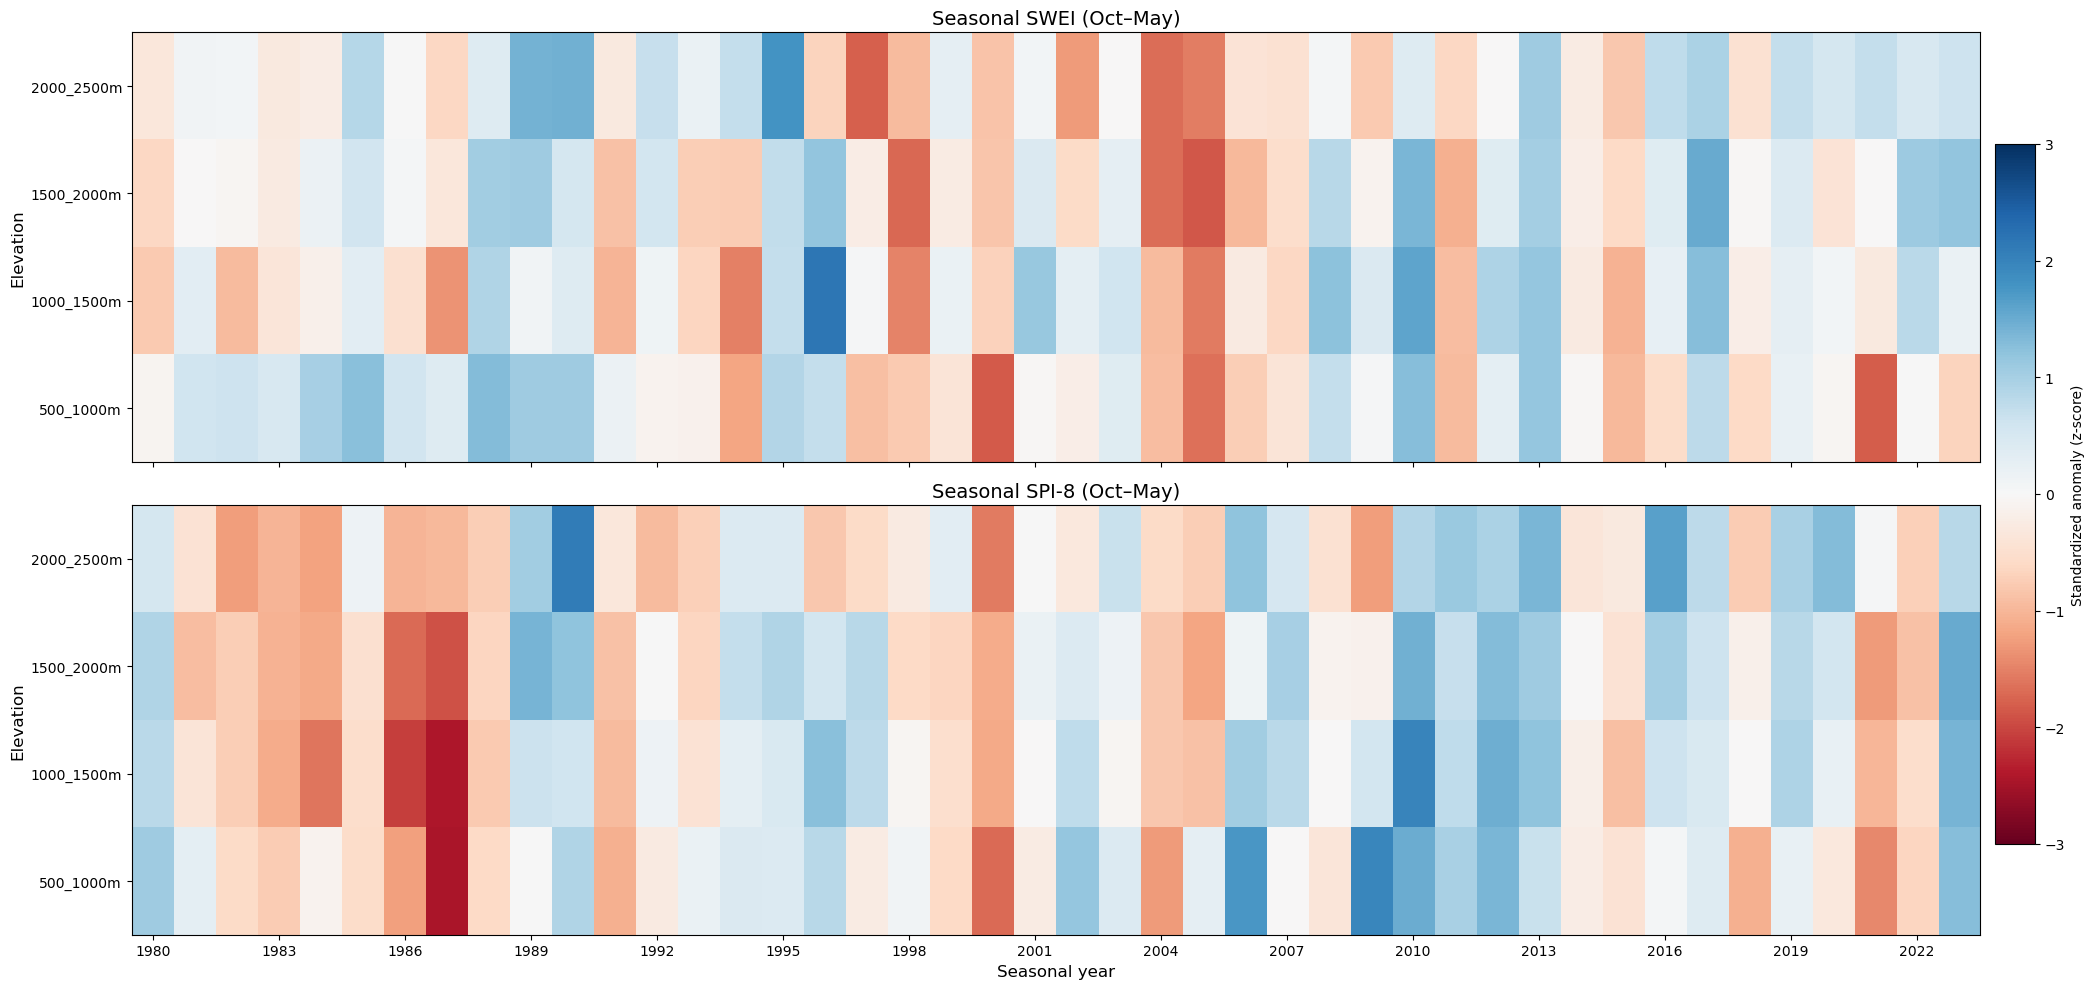

In [108]:
# Define elevation order explicitly
elev_order = ['2000_2500m','1500_2000m','1000_1500m','500_1000m']

# Pivot SPI
spi_mat = spi_8mo_avg.pivot_table(
    index="Elevation_Category",
    columns="Seasonal_Year",
    values="Avg_SPI_8mo"
).reindex(elev_order)

# Pivot SWEI
swei_mat = swei_8mo_avg.pivot_table(
    index="Elevation_Category",
    columns="Seasonal_Year",
    values="Avg_SWEI_8mo"
).reindex(elev_order)


# Keep only common years
common_years = sorted(set(spi_mat.columns).intersection(set(swei_mat.columns)))
spi_mat = spi_mat[common_years]
swei_mat = swei_mat[common_years]


# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

vlim = 3  # same scale for both

im1 = axes[0].imshow(swei_mat.values, aspect="auto",
                     cmap="RdBu", vmin=-vlim, vmax=vlim)
axes[0].set_title("Seasonal SWEI (Oct–May)", fontsize=14)
axes[0].set_ylabel("Elevation", fontsize=12)
axes[0].set_yticks(np.arange(len(swei_mat.index)))
axes[0].set_yticklabels(swei_mat.index)

im2 = axes[1].imshow(spi_mat.values, aspect="auto",
                     cmap="RdBu", vmin=-vlim, vmax=vlim)
axes[1].set_title("Seasonal SPI-8 (Oct–May)", fontsize=14)
axes[1].set_ylabel("Elevation", fontsize=12)
axes[1].set_xlabel("Seasonal year", fontsize=12)
axes[1].set_yticks(np.arange(len(spi_mat.index)))
axes[1].set_yticklabels(spi_mat.index)

# X-axis ticks (years)
years = common_years
step = max(1, len(years)//12)
axes[1].set_xticks(np.arange(len(years))[::step])
axes[1].set_xticklabels(years[::step])

# Shared colorbar on the right, outside the axes
# Place colorbar outside the main plot area
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label("Standardized anomaly (z-score)")

plt.tight_layout()
# save figure
#out_file_heatmap = config['SWEI_plots'] / f'SWEI_SPI_bow_basin_8month_heatmap.png'
#fig.savefig(out_file_heatmap, dpi=300, bbox_inches='tight')
plt.show()

In [84]:
# merge SWEI and SPI data for comparison
swei_spi_comparison = swei_8mo_avg.merge(
    spi_8mo_avg,
    on=['Elevation_Category', 'Seasonal_Year', 'month'],
    how='inner',
    suffixes=('_SWEI', '_SPI')
)
display(swei_spi_comparison)

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_8mo,Avg_SPI_8mo
0,1000_1500m,1980,5,-0.778473,0.813369
1,1000_1500m,1981,5,0.320094,-0.395595
2,1000_1500m,1982,5,-0.942805,-0.728869
3,1000_1500m,1983,5,-0.356098,-1.105589
4,1000_1500m,1984,5,-0.147442,-1.615920
...,...,...,...,...,...
171,500_1000m,2019,5,0.225988,0.215236
172,500_1000m,2020,5,-0.047313,-0.307270
173,500_1000m,2021,5,-1.810268,-1.442786
174,500_1000m,2022,5,0.020820,-0.636091


In [85]:
# calculate difference between SWEI and SPI
swei_spi_comparison['SPI_minus_SWEI'] = swei_spi_comparison['Avg_SPI_8mo'] - swei_spi_comparison['Avg_SWEI_8mo']
display(swei_spi_comparison)

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_8mo,Avg_SPI_8mo,SPI_minus_SWEI
0,1000_1500m,1980,5,-0.778473,0.813369,1.591843
1,1000_1500m,1981,5,0.320094,-0.395595,-0.715689
2,1000_1500m,1982,5,-0.942805,-0.728869,0.213936
3,1000_1500m,1983,5,-0.356098,-1.105589,-0.749491
4,1000_1500m,1984,5,-0.147442,-1.615920,-1.468478
...,...,...,...,...,...,...
171,500_1000m,2019,5,0.225988,0.215236,-0.010752
172,500_1000m,2020,5,-0.047313,-0.307270,-0.259958
173,500_1000m,2021,5,-1.810268,-1.442786,0.367482
174,500_1000m,2022,5,0.020820,-0.636091,-0.656911


In [99]:
# print 1986 values for each elevation category
for elev_cat in swei_spi_comparison['Elevation_Category'].unique():
    row = swei_spi_comparison[
        (swei_spi_comparison['Elevation_Category'] == elev_cat) &
        (swei_spi_comparison['Seasonal_Year'] == 1987) &
        (swei_spi_comparison['month'] == 5)
    ]
    if not row.empty:
        print(f"Elevation Category: {elev_cat}, May 1987 - Avg_SWEI_8mo: {row['Avg_SWEI_8mo'].values[0]:.2f}, Avg_SPI_8mo: {row['Avg_SPI_8mo'].values[0]:.2f}, SPI_minus_SWEI: {row['SPI_minus_SWEI'].values[0]:.2f}")



Elevation Category: 1000_1500m, May 1987 - Avg_SWEI_8mo: -1.34, Avg_SPI_8mo: -2.43, SPI_minus_SWEI: -1.09
Elevation Category: 1500_2000m, May 1987 - Avg_SWEI_8mo: -0.33, Avg_SPI_8mo: -1.90, SPI_minus_SWEI: -1.57
Elevation Category: 2000_2500m, May 1987 - Avg_SWEI_8mo: -0.61, Avg_SPI_8mo: -0.97, SPI_minus_SWEI: -0.35
Elevation Category: 500_1000m, May 1987 - Avg_SWEI_8mo: 0.39, Avg_SPI_8mo: -2.44, SPI_minus_SWEI: -2.83


In [86]:
#max and min  values in the difference
max_diff = swei_spi_comparison['SPI_minus_SWEI'].max()
min_diff = swei_spi_comparison['SPI_minus_SWEI'].min()
print(f"Maximum SPI - SWEI difference: {max_diff}")
print(f"Minimum SPI - SWEI difference: {min_diff}")

Maximum SPI - SWEI difference: 2.4889644718313537
Minimum SPI - SWEI difference: -2.831380040693296


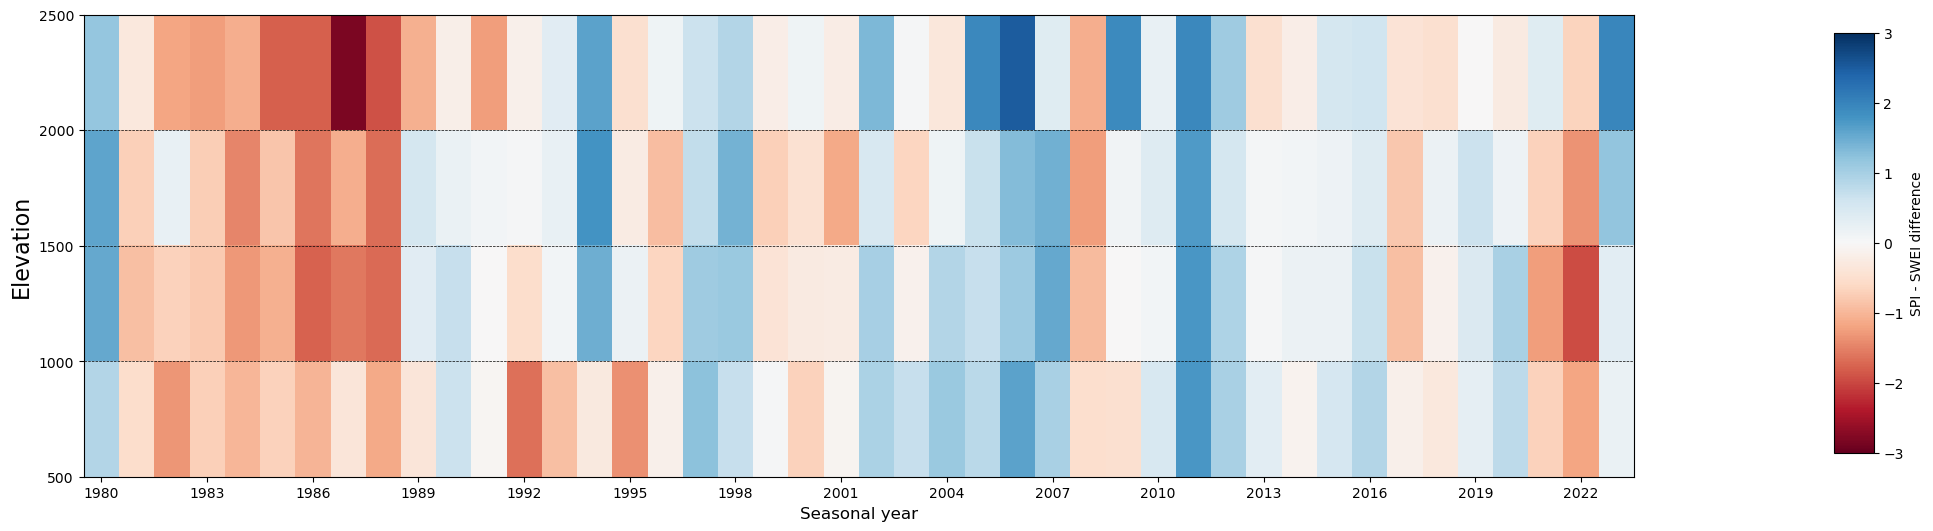

In [141]:
# plot heat map for the diffrence between SWEI and SPI

# Pivot SPI-SWEI
spi_swei_mat = swei_spi_comparison.pivot_table(
    index="Elevation_Category",
    columns="Seasonal_Year",
    values="SPI_minus_SWEI"
).reindex(elev_order)

# Single plot (reuse same axis for both references below)
fig, ax = plt.subplots(1, 1, figsize=(20, 6))
axes = np.array([ax, ax])  # axes[0] and axes[1] both point to the same Axes

# Years used for x-axis labelling
common_years = spi_swei_mat.columns.tolist()

vlim = 3 

im1 = axes[0].imshow(spi_swei_mat.values, aspect="auto",
                     cmap="RdBu", vmin=-vlim, vmax=vlim)
#axes[0].set_title("Difference between Seasonal SPI and SWEI (Oct–May)", fontsize=14)
axes[0].set_ylabel("Elevation", fontsize=16)
axes[0].set_yticks(np.arange(len(spi_swei_mat.index)))
axes[0].set_yticklabels(spi_swei_mat.index)

# Y-axis: numeric elevation ticks and dividing lines between categories
# Replot with explicit extent so that integer y positions are bin borders
n_elev = spi_swei_mat.shape[0]

# Older Matplotlib versions do not support `clear()` on ArtistList (axes[0].images),
# so we directly add a new image without attempting to clear the existing one.
im1 = axes[0].imshow(
    spi_swei_mat.values,
    aspect="auto",
    cmap="RdBu",
    vmin=-vlim,
    vmax=vlim,
    extent=[0, spi_swei_mat.shape[1], 500, 2500],
    origin="upper",
)

# Tick positions at category boundaries (500..2500)
yticks = [500, 1000, 1500, 2000, 2500]
# Labels in meters at boundaries
ylabels = ['500', '1000', '1500', '2000', '2500']

axes[0].set_yticks(yticks)
axes[0].set_yticklabels(ylabels)

# Horizontal grid lines at each elevation boundary
axes[0].grid(axis='y', color='black', linestyle='--', linewidth=0.5)

# X-axis ticks (years)
years = common_years
step = max(1, len(years)//12)
axes[1].set_xticks(np.arange(len(years))[::step]+0.5)  # +0.5 to center ticks between columns
axes[1].set_xticklabels(years[::step])
axes[1].set_xlabel("Seasonal year", fontsize=12)

# Shared colorbar on the right, outside the axes
# Place colorbar outside the main plot area
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label("SPI - SWEI difference")
#plt.tight_layout()
# save figure
#out_file_heatmap_diff = config['SWEI_plots'] / f'SWEI_minus_SPI_bow_basin_8month_heatmap.png'
#fig.savefig(out_file_heatmap_diff, dpi=1000, bbox_inches='tight')
plt.show()

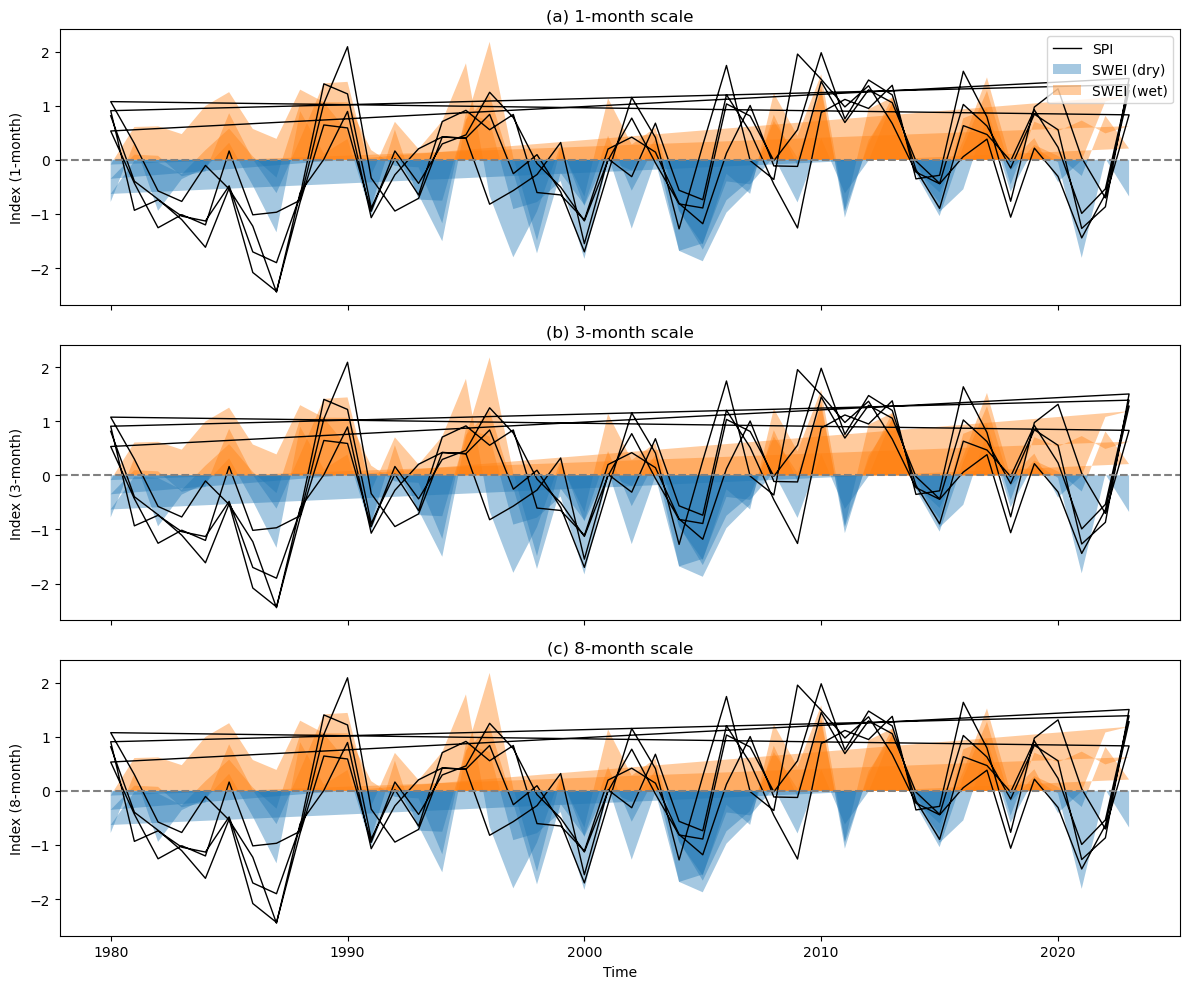

In [115]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

scales = [1, 3, 8]

for i, scale in enumerate(scales):
    ax = axes[i]

    spi = swei_spi_comparison['Avg_SPI_8mo']
    swei = swei_spi_comparison['Avg_SWEI_8mo']
    time = swei_spi_comparison['Seasonal_Year']

    # Plot SPI (reference)
    ax.plot(time, spi, color='black', linewidth=1, label='SPI')

    # Shade SWEI
    ax.fill_between(time, swei, 0, where=(swei < 0),
                    interpolate=True, alpha=0.4, label='SWEI (dry)')
    ax.fill_between(time, swei, 0, where=(swei > 0),
                    interpolate=True, alpha=0.4, label='SWEI (wet)')

    # Zero line
    ax.axhline(0, color='gray', linestyle='--')

    ax.set_ylabel(f'Index ({scale}-month)')
    ax.set_title(f'({chr(97+i)}) {scale}-month scale')

# One legend only
axes[0].legend(loc='upper right')

plt.xlabel('Time')
plt.tight_layout()
plt.show()

# Wilcoxon Signed Rank Test 

In [100]:
# 8-months (seasonal) SPI minus SWEI comparison by elevation category with Wilcoxon signed-rank test

# choose data from 1990
swei_spi_comparison_8monthly = swei_spi_comparison[swei_spi_comparison['Seasonal_Year'] >= 1994]

for elev_cat, grp in swei_spi_comparison_8monthly.groupby('Elevation_Category'):
    diff = grp['SPI_minus_SWEI']

    stat, p_value = wilcoxon(diff,alternative='greater')

    print(f"Elevation category: {elev_cat}")
    print(f"  Wilcoxon statistic = {stat:.3f}")
    print(f"  p-value = {p_value:.4f}\n")

Elevation category: 1000_1500m
  Wilcoxon statistic = 283.000
  p-value = 0.1543

Elevation category: 1500_2000m
  Wilcoxon statistic = 316.000
  p-value = 0.0440

Elevation category: 2000_2500m
  Wilcoxon statistic = 322.000
  p-value = 0.0333

Elevation category: 500_1000m
  Wilcoxon statistic = 325.000
  p-value = 0.0288



In [101]:
for elev_cat, grp in swei_spi_comparison_8monthly.groupby('Elevation_Category'):
    diff = grp['SPI_minus_SWEI']
    diff = diff[diff != 0]   # remove zero differences
    stat, p_value = wilcoxon(diff, alternative='greater')
    
    N = len(diff)
    # Wilcoxon mean and std
    mu_w = N * (N + 1) / 4
    sigma_w = np.sqrt(N * (N + 1) * (2 * N + 1) / 24)

    # Z-score
    z = (stat - mu_w) / sigma_w

        # Effect size
    r = abs(z) / np.sqrt(N)

    print(f"Elevation category: {elev_cat}")
    print(f"N = {N}")
    print(f"Z = {z:.3f}")
    print(f"Effect size r = {r:.3f}")

    

Elevation category: 1000_1500m
N = 30
Z = 1.039
Effect size r = 0.190
Elevation category: 1500_2000m
N = 30
Z = 1.717
Effect size r = 0.314
Elevation category: 2000_2500m
N = 30
Z = 1.841
Effect size r = 0.336
Elevation category: 500_1000m
N = 30
Z = 1.903
Effect size r = 0.347


In [102]:
stat, p_value = wilcoxon(diff, alternative='greater')

print(f"p-value = {p_value:.4f}")

p-value = 0.0288


In [103]:
# monthly SPI minus SWEI comparison by elevation category with Wilcoxon signed-rank test

# merge SPI and SWEI for monthly comparison
swei_spi_comparison_monthly = swei_1mo_avg.merge(
    spi_1mo_avg,
    on=['Elevation_Category', 'Seasonal_Year', 'month'],
    how='inner',
    suffixes=('_SWEI', '_SPI')
)

# add difference column
swei_spi_comparison_monthly['SPI_minus_SWEI'] = swei_spi_comparison_monthly['Avg_SPI_1mo'] - swei_spi_comparison_monthly['Avg_SWEI_1mo']


# choose data from 1994
swei_spi_comparison_monthly = swei_spi_comparison_monthly[swei_spi_comparison_monthly['Seasonal_Year'] >= 1993]

# Group by month, then by elevation category within each month
for month, month_df in swei_spi_comparison_monthly.groupby('month'):
    print(f"\nMonth: {month}")
    
    for elev_cat, grp in month_df.groupby('Elevation_Category'):
        diff = grp['SPI_minus_SWEI']

        stat, p_value = wilcoxon(diff)

        print(f"  Elevation category: {elev_cat}")
        print(f"    Wilcoxon statistic = {stat:.3f}")
        print(f"    p-value = {p_value:.4f}")


Month: 1
  Elevation category: 1000_1500m
    Wilcoxon statistic = 221.000
    p-value = 0.6083
  Elevation category: 1500_2000m
    Wilcoxon statistic = 218.000
    p-value = 0.5682
  Elevation category: 2000_2500m
    Wilcoxon statistic = 247.000
    p-value = 0.9923
  Elevation category: 500_1000m
    Wilcoxon statistic = 122.000
    p-value = 0.0124

Month: 2
  Elevation category: 1000_1500m
    Wilcoxon statistic = 223.000
    p-value = 0.6357
  Elevation category: 1500_2000m
    Wilcoxon statistic = 217.000
    p-value = 0.5551
  Elevation category: 2000_2500m
    Wilcoxon statistic = 201.000
    p-value = 0.3673
  Elevation category: 500_1000m
    Wilcoxon statistic = 147.000
    p-value = 0.0479

Month: 3
  Elevation category: 1000_1500m
    Wilcoxon statistic = 231.000
    p-value = 0.7498
  Elevation category: 1500_2000m
    Wilcoxon statistic = 212.000
    p-value = 0.4919
  Elevation category: 2000_2500m
    Wilcoxon statistic = 174.000
    p-value = 0.1517
  Elevation cat

In [104]:
# 3-monthly SPI minus SWEI comparison by elevation category with Wilcoxon signed-rank test

# merge SPI and SWEI for monthly comparison
swei_spi_comparison_3monthly = swei_3mo_avg.merge(
    spi_3mo_avg,
    on=['Elevation_Category', 'Seasonal_Year', 'month'],
    how='inner',
    suffixes=('_SWEI', '_SPI')
)

# add difference column
swei_spi_comparison_3monthly['SPI_minus_SWEI'] = swei_spi_comparison_3monthly['Avg_SPI_3mo'] - swei_spi_comparison_3monthly['Avg_SWEI_3mo']


# choose data from 1994
swei_spi_comparison_3monthly = swei_spi_comparison_3monthly[swei_spi_comparison_3monthly['Seasonal_Year'] >= 1993]

# Group by month, then by elevation category within each month
for month, month_df in swei_spi_comparison_3monthly.groupby('month'):
    print(f"\nMonth: {month}")
    
    for elev_cat, grp in month_df.groupby('Elevation_Category'):
        diff = grp['SPI_minus_SWEI']

        stat, p_value = wilcoxon(diff)

        print(f"  Elevation category: {elev_cat}")
        print(f"    Wilcoxon statistic = {stat:.3f}")
        print(f"    p-value = {p_value:.4f}")


Month: 1
  Elevation category: 1000_1500m
    Wilcoxon statistic = 163.000
    p-value = 0.0982
  Elevation category: 1500_2000m
    Wilcoxon statistic = 143.000
    p-value = 0.0394
  Elevation category: 2000_2500m
    Wilcoxon statistic = 223.000
    p-value = 0.6357
  Elevation category: 500_1000m
    Wilcoxon statistic = 44.000
    p-value = 0.0000

Month: 2
  Elevation category: 1000_1500m
    Wilcoxon statistic = 177.000
    p-value = 0.1694
  Elevation category: 1500_2000m
    Wilcoxon statistic = 161.000
    p-value = 0.0903
  Elevation category: 2000_2500m
    Wilcoxon statistic = 237.000
    p-value = 0.8393
  Elevation category: 500_1000m
    Wilcoxon statistic = 88.000
    p-value = 0.0012

Month: 3
  Elevation category: 1000_1500m
    Wilcoxon statistic = 230.000
    p-value = 0.7352
  Elevation category: 1500_2000m
    Wilcoxon statistic = 189.000
    p-value = 0.2556
  Elevation category: 2000_2500m
    Wilcoxon statistic = 216.000
    p-value = 0.5422
  Elevation categ

# Heldmuyer classification

In [119]:
# load data
SD_clasification_data = casr_data[['station_id', 'time', 'lon', 'lat', 'Elevation_Category', 'Seasonal_Year', 'SWE','Precipitation']]

display(SD_clasification_data.head())


,station_id,time,lon,lat,Elevation_Category,Seasonal_Year,SWE,Precipitation
0,1,1980-10-10,-116.1380,51.3346,2000_2500m,1980,0.878418,0.009879
2,2,1983-10-12,-116.1875,51.4191,2000_2500m,1983,6.875000,0.023846
3,2,1980-12-11,-116.1875,51.4191,2000_2500m,1980,118.125000,4.578907
5,2,1982-10-29,-116.1875,51.4191,2000_2500m,1982,23.125000,1.777088
6,2,1982-01-18,-116.1875,51.4191,2000_2500m,1981,145.000000,1.890419


In [121]:
# find peak SWE per each Grid point and Seasonala_Year
peak_idx = (
    SD_clasification_data
    .groupby(['station_id', 'Seasonal_Year'])['SWE']
    .idxmax()
)

peak_SWE_data = (
    SD_clasification_data
    .loc[peak_idx, ['station_id', 'Elevation_Category','lon','lat','Seasonal_Year', 'time', 'SWE']]
    .rename(columns={'time': 'Peak_SWE_Date', 'SWE': 'Peak_SWE'})
    .reset_index(drop=True)
)

display(peak_SWE_data.head())

,station_id,Elevation_Category,lon,lat,Seasonal_Year,Peak_SWE_Date,Peak_SWE
0,1,2000_2500m,-116.138,51.3346,1980,1981-05-12,240.625
1,1,2000_2500m,-116.138,51.3346,1981,1982-05-09,277.000
2,1,2000_2500m,-116.138,51.3346,1982,1983-04-11,273.875
3,1,2000_2500m,-116.138,51.3346,1983,1984-04-12,200.375
4,1,2000_2500m,-116.138,51.3346,1984,1985-04-29,227.750


In [122]:
# calculate meanpeak SWE per Elevation category and Seasonal Year
mean_peak_SWE = (
    peak_SWE_data
    .groupby(['Elevation_Category', 'Seasonal_Year'], as_index=False)
    .agg(Mean_Peak_SWE=('Peak_SWE', 'mean'))
)
display(mean_peak_SWE.head(15))

,Elevation_Category,Seasonal_Year,Mean_Peak_SWE
0,1000_1500m,1980,40.117253
1,1000_1500m,1981,29.995833
2,1000_1500m,1982,17.079167
3,1000_1500m,1983,30.662508
4,1000_1500m,1984,23.369173
5,1000_1500m,1985,33.612565
6,1000_1500m,1986,24.904169
7,1000_1500m,1987,25.312655
8,1000_1500m,1988,39.641667
9,1000_1500m,1989,30.152865


In [123]:
# compute climatological peak SWE per Elevation category 1991-2020
clim_peak_SWE = (
    mean_peak_SWE
    .loc[mean_peak_SWE['Seasonal_Year'].between(1991, 2020)]
    .groupby('Elevation_Category', as_index=False)
    .agg(Climatological_Peak_SWE=('Mean_Peak_SWE', 'mean'))
)   
display(clim_peak_SWE.head(10))

,Elevation_Category,Climatological_Peak_SWE
0,1000_1500m,33.787892
1,1500_2000m,47.861118
2,2000_2500m,145.828157
3,500_1000m,33.579055


In [124]:
# 5% of climatological peak SWE per Elevation category
clim_peak_SWE['onset_SWE'] = clim_peak_SWE['Climatological_Peak_SWE'] * 0.05
display(clim_peak_SWE.head(10))

,Elevation_Category,Climatological_Peak_SWE,onset_SWE
0,1000_1500m,33.787892,1.689395
1,1500_2000m,47.861118,2.393056
2,2000_2500m,145.828157,7.291408
3,500_1000m,33.579055,1.678953


In [126]:
# select data between peak_swe of the season and clim_peak_swe date for each grid and seasonal year

# Initialize an empty DataFrame to store the results
onset_to_peak = pd.DataFrame()

# Iterate through each coordinate_id
for coordinate_id in SD_clasification_data['station_id'].unique():
    # Filter the data for the current coordinate_id
    coord_data = SD_clasification_data[SD_clasification_data['station_id'] == coordinate_id]
    
    # Iterate through each season year for the current coordinate_id
    for year in coord_data['Seasonal_Year'].unique():
        # Filter the data for the current season year
        season_data = coord_data[coord_data['Seasonal_Year'] == year]
        
        # Get the elevation category for this group
        elev_cat = season_data['Elevation_Category'].iloc[0]

        # Get the correct threshold for this elevation category from clim_peak_SWE
        row = clim_peak_SWE.loc[
            clim_peak_SWE['Elevation_Category'] == elev_cat,
            'onset_SWE'
        ]
        if row.empty or pd.isna(row.iloc[0]):
            continue  # no threshold defined for this elevation band

        threshold = row.iloc[0]

        # Find the onset date (first date SWE >= threshold)
        onset_mask = season_data['SWE'] >= threshold
        if not onset_mask.any():
            continue  # no onset for this season/grid

        onset_date = season_data.loc[onset_mask, 'time'].min()
        
        # Find the peak date
        peak_date = season_data[season_data['SWE'] == season_data['SWE'].max()]['time'].values[0]
        
        # Select data from onset to peak
        selected_data = season_data[(season_data['time'] >= onset_date) & (season_data['time'] <= peak_date)]
        
        # Append the selected data to the result DataFrame
        onset_to_peak = pd.concat([onset_to_peak, selected_data])

# Reset the index of the result DataFrame
onset_to_peak.reset_index(drop=True, inplace=True)

# save the result to a CSV file
onset_to_peak.to_csv(config['classification_output_dir'] /  'onset_to_peak_data.csv', index=False)

# Display the result
display(onset_to_peak)


,station_id,time,lon,lat,Elevation_Category,Seasonal_Year,SWE,Precipitation
0,1,1981-02-11,-116.1380,51.3346,2000_2500m,1980,152.250000,0.000000
1,1,1980-11-07,-116.1380,51.3346,2000_2500m,1980,27.000000,2.128011
2,1,1980-12-21,-116.1380,51.3346,2000_2500m,1980,110.625000,3.271602
3,1,1980-10-25,-116.1380,51.3346,2000_2500m,1980,12.625000,0.000000
4,1,1980-11-13,-116.1380,51.3346,2000_2500m,1980,40.500000,0.007695
...,...,...,...,...,...,...,...,...
1427070,257,2022-11-08,-111.6202,50.0960,500_1000m,2022,23.125000,5.015135
1427071,257,2022-11-04,-111.6202,50.0960,500_1000m,2022,8.500000,0.026440
1427072,257,2022-10-24,-111.6202,50.0960,500_1000m,2022,0.625000,4.340502
1427073,257,2022-10-30,-111.6202,50.0960,500_1000m,2022,0.000061,0.001129


In [128]:
# take cum sum of Precipitation and mean SWE over each Seasonal_Year, per grid
SD_clasification_data = SD_clasification_data.sort_values(
    ['station_id', 'Seasonal_Year', 'time']
).copy()

SD_clasification_data['Cumulative_Precipitation'] = (
    SD_clasification_data
    .groupby(['station_id', 'Seasonal_Year'])['Precipitation']
    .cumsum()
)

# get max cumulative Precipitation and mean SWE for each grid and Seasonal_Year
seasonal_maxcumP_meanSWE = (
    SD_clasification_data
    .groupby(['station_id', 'Seasonal_Year', 'lon', 'lat', 'Elevation_Category'], as_index=False)
    .agg(
        Max_Cumulative_Precipitation=('Cumulative_Precipitation', 'max'),
        Mean_SWE=('SWE', 'mean')
    )
)

display(seasonal_maxcumP_meanSWE.head(15))

,station_id,Seasonal_Year,lon,lat,Elevation_Category,Max_Cumulative_Precipitation,Mean_SWE
0,1,1980,-116.138,51.3346,2000_2500m,330.692535,124.720065
1,1,1981,-116.138,51.3346,2000_2500m,321.687604,141.946829
2,1,1982,-116.138,51.3346,2000_2500m,231.587842,140.776336
3,1,1983,-116.138,51.3346,2000_2500m,272.967472,114.779913
4,1,1984,-116.138,51.3346,2000_2500m,258.220625,110.846370
5,1,1985,-116.138,51.3346,2000_2500m,366.266071,167.173256
6,1,1986,-116.138,51.3346,2000_2500m,304.387351,112.710529
7,1,1987,-116.138,51.3346,2000_2500m,296.970781,101.974434
8,1,1988,-116.138,51.3346,2000_2500m,353.303776,147.406806
9,1,1989,-116.138,51.3346,2000_2500m,420.539197,205.707166


In [129]:
mean_cumP_by_elev = seasonal_maxcumP_meanSWE.groupby('Elevation_Category')['Max_Cumulative_Precipitation'].mean().reset_index()
mean_cumP_by_elev = mean_cumP_by_elev.rename(columns={'Max_Cumulative_Precipitation': 'mean_max_cumulative_P'})

display(mean_cumP_by_elev)

,Elevation_Category,mean_max_cumulative_P
0,1000_1500m,198.791563
1,1500_2000m,254.289177
2,2000_2500m,322.600551
3,500_1000m,150.882044


In [130]:
# Merge the mean back to the main DataFrame
onset_to_peak_mean_filtered = seasonal_maxcumP_meanSWE.merge(
    mean_cumP_by_elev,
    on='Elevation_Category',
    how='left'
)

display(onset_to_peak_mean_filtered)

,station_id,Seasonal_Year,lon,lat,Elevation_Category,Max_Cumulative_Precipitation,Mean_SWE,mean_max_cumulative_P
0,1,1980,-116.1380,51.3346,2000_2500m,330.692535,124.720065,322.600551
1,1,1981,-116.1380,51.3346,2000_2500m,321.687604,141.946829,322.600551
2,1,1982,-116.1380,51.3346,2000_2500m,231.587842,140.776336,322.600551
3,1,1983,-116.1380,51.3346,2000_2500m,272.967472,114.779913,322.600551
4,1,1984,-116.1380,51.3346,2000_2500m,258.220625,110.846370,322.600551
...,...,...,...,...,...,...,...,...
11303,257,2019,-111.6202,50.0960,500_1000m,143.209873,2.395867,150.882044
11304,257,2020,-111.6202,50.0960,500_1000m,123.811036,2.383157,150.882044
11305,257,2021,-111.6202,50.0960,500_1000m,87.313718,1.164792,150.882044
11306,257,2022,-111.6202,50.0960,500_1000m,124.308624,3.057855,150.882044


In [131]:
# Calculations to plot graphs
onset_to_peak_mean_filtered['SWE_P_ratio'] = (
    onset_to_peak_mean_filtered['Mean_SWE'] /
    onset_to_peak_mean_filtered['Max_Cumulative_Precipitation']
)

onset_to_peak_mean_filtered['Cum_P_anomaly'] = (
    onset_to_peak_mean_filtered['Max_Cumulative_Precipitation'] -
    onset_to_peak_mean_filtered['mean_max_cumulative_P']
)

display(onset_to_peak_mean_filtered)

,station_id,Seasonal_Year,lon,lat,Elevation_Category,Max_Cumulative_Precipitation,Mean_SWE,mean_max_cumulative_P,SWE_P_ratio,Cum_P_anomaly
0,1,1980,-116.1380,51.3346,2000_2500m,330.692535,124.720065,322.600551,0.377148,8.091984
1,1,1981,-116.1380,51.3346,2000_2500m,321.687604,141.946829,322.600551,0.441257,-0.912947
2,1,1982,-116.1380,51.3346,2000_2500m,231.587842,140.776336,322.600551,0.607874,-91.012709
3,1,1983,-116.1380,51.3346,2000_2500m,272.967472,114.779913,322.600551,0.420489,-49.633079
4,1,1984,-116.1380,51.3346,2000_2500m,258.220625,110.846370,322.600551,0.429270,-64.379926
...,...,...,...,...,...,...,...,...,...,...
11303,257,2019,-111.6202,50.0960,500_1000m,143.209873,2.395867,150.882044,0.016730,-7.672171
11304,257,2020,-111.6202,50.0960,500_1000m,123.811036,2.383157,150.882044,0.019248,-27.071008
11305,257,2021,-111.6202,50.0960,500_1000m,87.313718,1.164792,150.882044,0.013340,-63.568326
11306,257,2022,-111.6202,50.0960,500_1000m,124.308624,3.057855,150.882044,0.024599,-26.573420


In [132]:
# take mean over Elevation_Category and Seasonal_Year
final_classification_data = (
    onset_to_peak_mean_filtered
    .groupby(['Elevation_Category', 'Seasonal_Year'], as_index=False)
    .agg(
        Avg_SWE_P_ratio=('SWE_P_ratio', 'mean'),
        Avg_Cum_P_anomaly=('Cum_P_anomaly', 'mean')
    )
)
display(final_classification_data)


,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly
0,1000_1500m,1980,0.017906,43.219919
1,1000_1500m,1981,0.043095,-27.761347
2,1000_1500m,1982,0.027718,-41.996265
3,1000_1500m,1983,0.037195,-60.840708
4,1000_1500m,1984,0.054673,-81.794527
...,...,...,...,...
171,500_1000m,2019,0.064201,6.323612
172,500_1000m,2020,0.055116,-20.557390
173,500_1000m,2021,0.022948,-64.727040
174,500_1000m,2022,0.067483,-35.737448


K - Mean Clustering

In [133]:
# Standardize cumulative_P_anomaly and mean_SWE/cumulative_P for each elevation category
final_classification_data['cum_P_anomaly_z'] = final_classification_data.groupby('Elevation_Category')['Avg_Cum_P_anomaly'].transform(
    lambda x: (x - x.mean()) / x.std()
)
final_classification_data['Avg_SWE_P_ratio_z'] = final_classification_data.groupby('Elevation_Category')['Avg_SWE_P_ratio'].transform(
    lambda x: (x - x.mean()) / x.std()
)

display(final_classification_data)

,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,cum_P_anomaly_z,Avg_SWE_P_ratio_z
0,1000_1500m,1980,0.017906,43.219919,0.816828,-1.268275
1,1000_1500m,1981,0.043095,-27.761347,-0.524671,0.261915
2,1000_1500m,1982,0.027718,-41.996265,-0.793701,-0.672196
3,1000_1500m,1983,0.037195,-60.840708,-1.149849,-0.096489
4,1000_1500m,1984,0.054673,-81.794527,-1.545862,0.965294
...,...,...,...,...,...,...
171,500_1000m,2019,0.064201,6.323612,0.131920,-0.212682
172,500_1000m,2020,0.055116,-20.557390,-0.428857,-0.325875
173,500_1000m,2021,0.022948,-64.727040,-1.350301,-0.726640
174,500_1000m,2022,0.067483,-35.737448,-0.745536,-0.171794


In [134]:
# K-means clustering for the whole drought dataset (no elevation separation)
cluster_features = final_classification_data[['Avg_SWE_P_ratio_z', 'cum_P_anomaly_z']]
kmean = KMeans(n_clusters=4, random_state=0)
final_classification_data['cluster'] = kmean.fit_predict(cluster_features)
print("Cluster centers:\n", kmean.cluster_centers_)

display(final_classification_data.head(15))

c:\Users\walimunige.rupasingh\AppData\Local\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster centers:
 [[-0.66773419  0.97268287]
 [-0.46917722 -0.58797911]
 [ 1.35910589 -0.93379358]
 [ 0.85001468  1.02979987]]


c:\Users\walimunige.rupasingh\AppData\Local\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\walimunige.rupasingh\AppData\Local\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,cum_P_anomaly_z,Avg_SWE_P_ratio_z,cluster
0,1000_1500m,1980,0.017906,43.219919,0.816828,-1.268275,0
1,1000_1500m,1981,0.043095,-27.761347,-0.524671,0.261915,1
2,1000_1500m,1982,0.027718,-41.996265,-0.793701,-0.672196,1
3,1000_1500m,1983,0.037195,-60.840708,-1.149849,-0.096489,1
4,1000_1500m,1984,0.054673,-81.794527,-1.545862,0.965294,2
5,1000_1500m,1985,0.057626,-33.927025,-0.641198,1.144714,2
6,1000_1500m,1986,0.069102,-98.364500,-1.859023,1.841849,2
7,1000_1500m,1987,0.045110,-111.069442,-2.099138,0.384328,2
8,1000_1500m,1988,0.076778,-46.554357,-0.879846,2.308174,2
9,1000_1500m,1989,0.036765,35.222244,0.665677,-0.122627,0


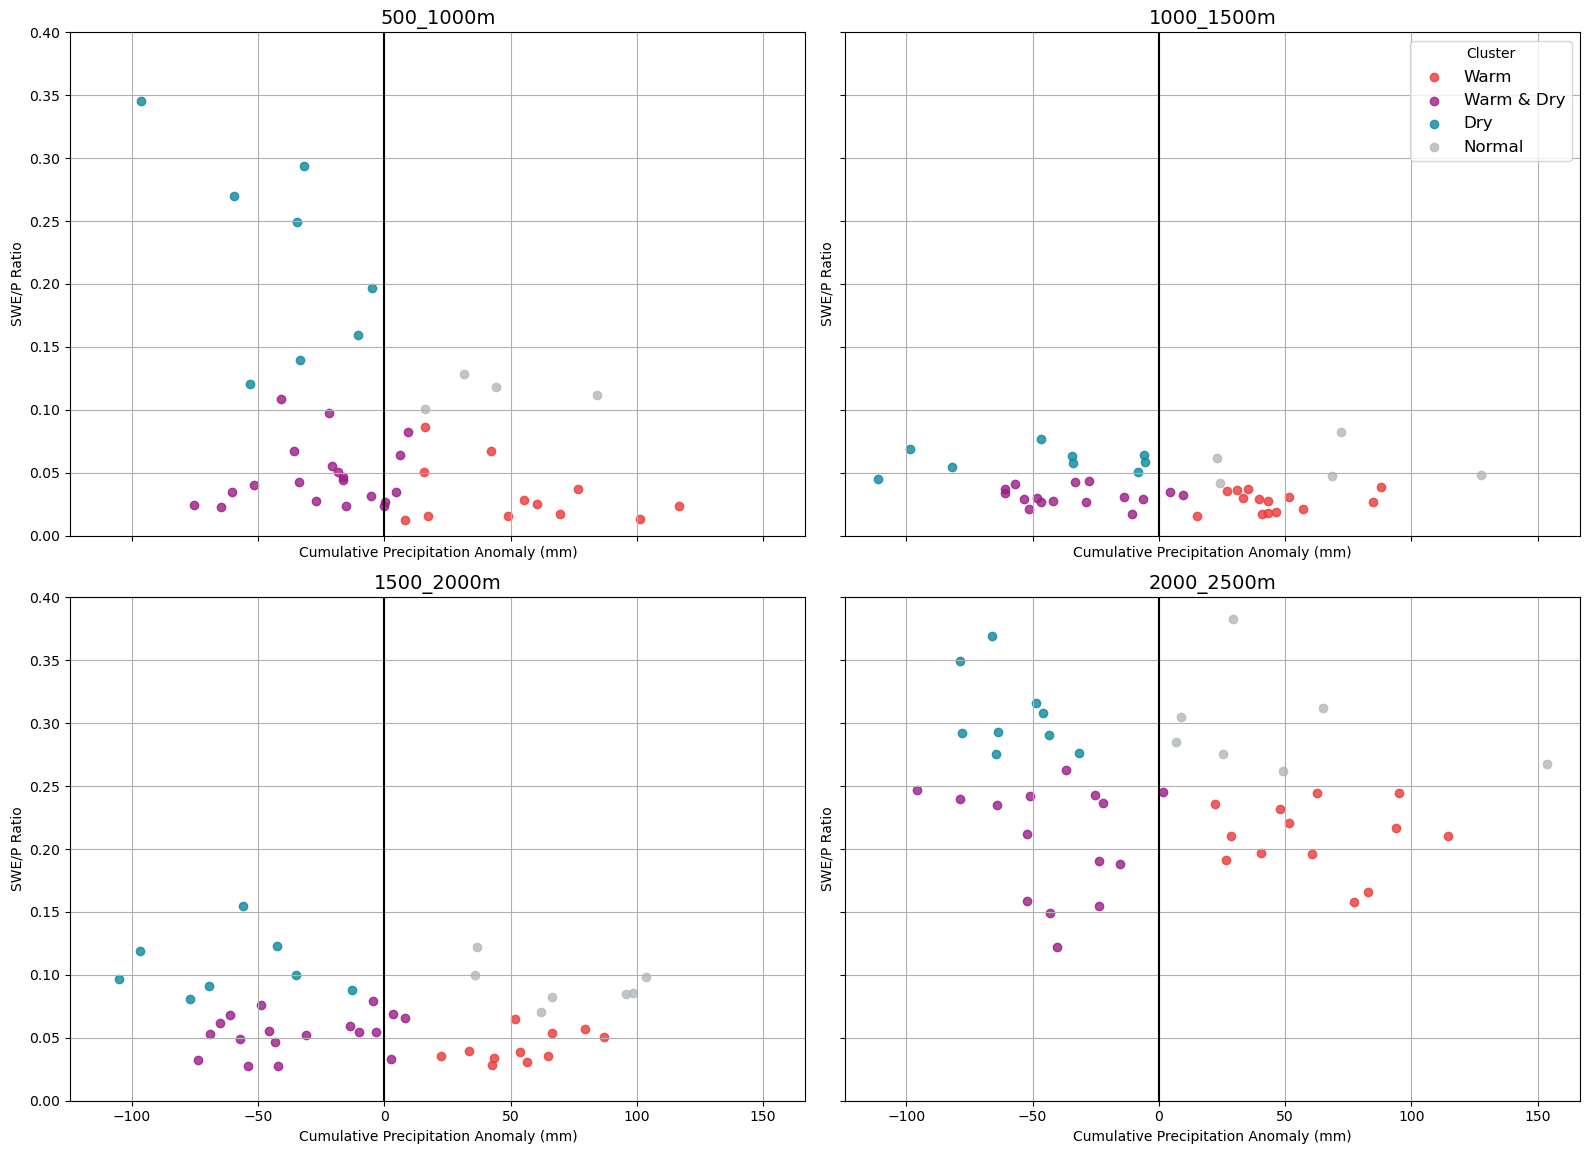

In [175]:
# Define cluster colors for plotting
cluster_colors = {
    "Warm": "#EB3A3A",         # orange
    "Warm & Dry": "#9C1C87",   # reddish
    "Dry": "#0C889E",          # blue
    "Normal": "#B2B8BD"       # grey for non-drought years    
    # Add more cluster names and colors as needed
}

# Map cluster numbers to cluster names
cluster_number_to_name = {0: "Warm", 1: "Warm & Dry", 2:  "Dry", 3: "Normal"}
final_classification_data['cluster_name'] = final_classification_data['cluster'].map(cluster_number_to_name)

# Create subplots for each elevation category
elevations = final_classification_data['Elevation_Category'].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Define desired elevation order
elev_order = ['500_1000m', '1000_1500m', '1500_2000m', '2000_2500m']
elevations_ordered = [e for e in elev_order if e in elevations]

for i, elev in enumerate(elevations_ordered):
    ax = axes[i]
    drought_subset = final_classification_data[
        final_classification_data['Elevation_Category'] == elev
    ]

    for cname, color in cluster_colors.items():
        cluster_points = drought_subset[drought_subset['cluster_name'] == cname]
        ax.scatter(
            cluster_points['Avg_Cum_P_anomaly'],
            cluster_points['Avg_SWE_P_ratio'],
            color=color,
            label=cname if i == 0 else "",  # Only label once for legend
            alpha=0.8
        )

    ax.axvline(0, color='black', linewidth=1.5, linestyle='-')
    ax.set_title(f'{elev}', fontsize=14)
    ax.set_xlabel('Cumulative Precipitation Anomaly (mm)')
    ax.set_ylabel('SWE/P Ratio')
    ax.grid(True)

# Add legend to the first subplot only
handles, labels = axes[0].get_legend_handles_labels()
# Place legend inside the top right subplot (axes[1])
axes[1].legend(handles, labels, title='Cluster', loc='upper right', fontsize=12)
#plt.suptitle('Snow Drought Classification for each Elevation Category', fontsize=18)
plt.ylim(0,0.4)
plt.savefig(config['classification_plots'] / 'Snow_Drought_Classification_by_Elevation.png', dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [137]:
# add season year for each cluster and elevation category to a summary table
 
# add season year for each cluster and elevation category to a summary table
 
name_to_col = {
    "Dry": "dry",
    "Warm & Dry": "dry&warm",
    "Warm": "warm",
    "Normal": "normal",
}

cluster_rows = []
for elev in elevations_ordered:
    drought_subset = final_classification_data[
        final_classification_data['Elevation_Category'] == elev
    ]
    row = {"Elevation_Category": elev}
    for cname, col in name_to_col.items():
        years = (
            drought_subset.loc[drought_subset['cluster_name'] == cname, 'Seasonal_Year']
            .dropna()
            .astype(int)
            .unique()
        )
        row[col] = sorted(years.tolist())
    cluster_rows.append(row)

sd_years_df = pd.DataFrame(cluster_rows)
display(sd_years_df)



,Elevation_Category,dry,dry&warm,warm,normal
0,500_1000m,"[1982, 1984, 1985, 1986, 1987, 1988, 1989, 1991]","[1981, 1983, 1992, 1993, 1997, 1998, 1999, 200...","[1980, 1994, 1996, 2002, 2003, 2005, 2006, 200...","[1990, 1995, 2010, 2013]"
1,1000_1500m,"[1984, 1985, 1986, 1987, 1988, 2001, 2003, 200...","[1981, 1982, 1983, 1991, 1992, 1993, 1998, 199...","[1980, 1989, 1990, 1994, 1997, 2002, 2006, 200...","[1995, 1996, 2010, 2013, 2017]"
2,1500_2000m,"[1984, 1985, 1986, 1987, 1988, 2008, 2021, 2022]","[1981, 1982, 1983, 1991, 1992, 1993, 1998, 199...","[1980, 1990, 1994, 1997, 2002, 2007, 2011, 201...","[1989, 1995, 1996, 2010, 2013, 2017, 2023]"
3,2000_2500m,"[1981, 1982, 1983, 1984, 1986, 1988, 1992, 199...","[1987, 1991, 1996, 1997, 1998, 2000, 2001, 200...","[1980, 1999, 2003, 2006, 2007, 2010, 2011, 201...","[1985, 1989, 1990, 1994, 1995, 2017, 2021]"


C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_33244\3271367344.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


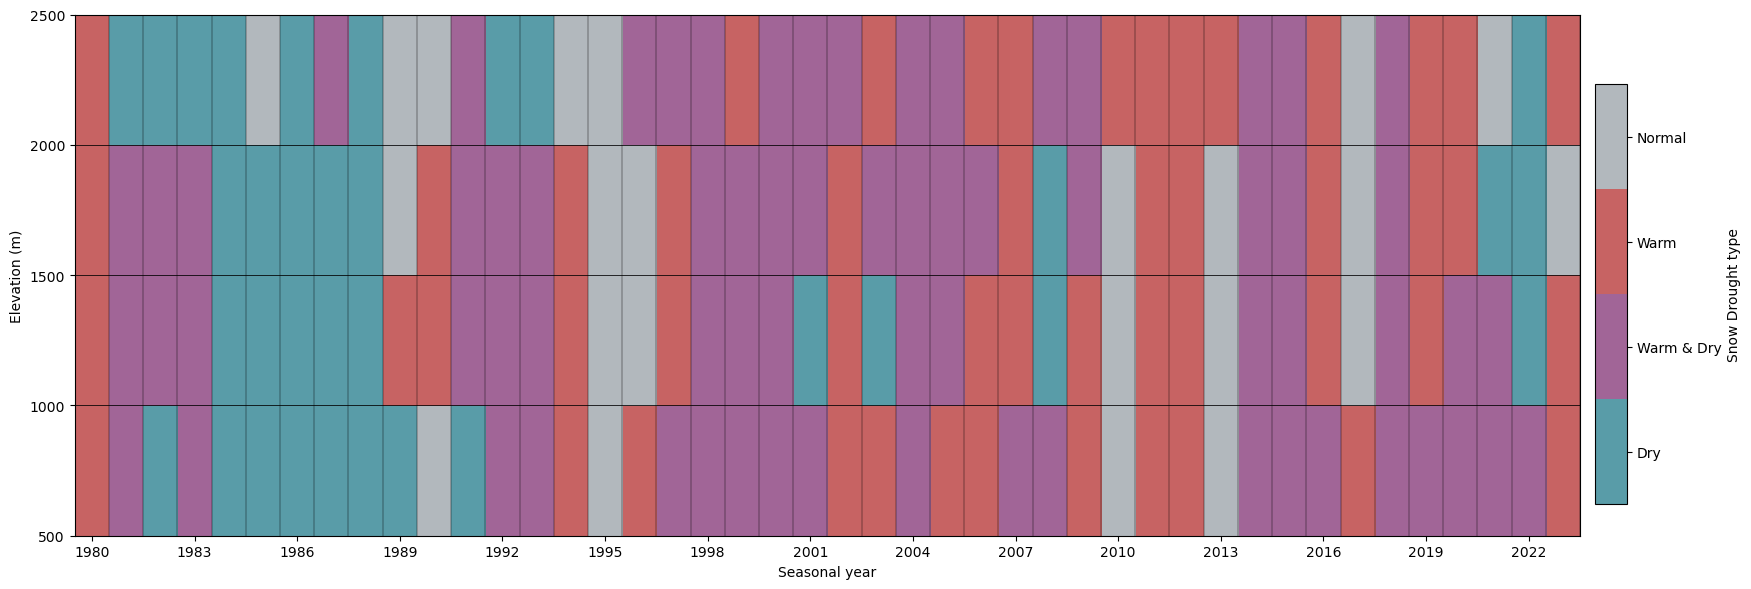

In [173]:
# ---- SORT elevation categories properly ----
elevation_order = ['500_1000m', '1000_1500m', '1500_2000m', '2000_2500m']
sd_years_df = sd_years_df.set_index('Elevation_Category').loc[elevation_order].reset_index()

elevations = sd_years_df['Elevation_Category'].values
all_years = sorted(final_classification_data['Seasonal_Year'].unique())

# ---- CREATE HEATMAP MATRIX ----
drought_types = ['dry', 'dry&warm', 'warm', 'normal']
heatmap_data = np.zeros((len(elevations), len(all_years)))

for i, elev in enumerate(elevations):
    elev_row = sd_years_df.iloc[i]
    for j, year in enumerate(all_years):
        for dtype in drought_types:
            if year in elev_row[dtype]:
                heatmap_data[i, j] = drought_types.index(dtype) + 1
                break

# ---- COLOR MAP (MATCH YOUR FIGURE EXACTLY) ----
drought_type_colors = {
    "Warm": "#C76363",
    "Warm & Dry": "#A16597",
    "Dry": "#599CA8",
    "Normal": "#B2B8BD"
}

colors_list = [
    'white',  # 0 (no data)
    drought_type_colors["Dry"],
    drought_type_colors["Warm & Dry"],
    drought_type_colors["Warm"],
    drought_type_colors["Normal"]
]

cmap = ListedColormap(colors_list)

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(16, 6))

im = ax.imshow(
    heatmap_data,
    aspect='auto',
    cmap=cmap,
    vmin=0,
    vmax=4
)

# ---- X AXIS (years) ----
ax.set_xticks(np.arange(len(all_years))[::3])
ax.set_xticklabels(all_years[::3])

# ---- Y AXIS as continuous elevation ----

# Tick positions at cell boundaries
y_positions = np.arange(-0.5, len(elevations) + 0.5, 1)

# Elevation labels
y_labels = ['500', '1000', '1500', '2000', '2500']

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)

# Horizontal grid lines at each elevation boundary
ax.hlines(y=y_positions, xmin=-0.5, xmax=len(all_years)-0.5,
          colors='black', linewidth=0.5)

# Optional: invert so 2500 is at top 
ax.invert_yaxis()

# ---- GRID LINES  ----
ax.set_xticks(np.arange(-0.5, len(all_years), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(elevations), 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=0.3)
ax.tick_params(which='minor', bottom=False, left=False)
ax.hlines(y=y_positions, xmin=-0.5, xmax=len(all_years)-0.5,
          colors='black', linewidth=0.4, alpha=0.5)

# ---- LABELS ----
#ax.set_title('Snow drought type (Oct–May)', fontsize=14)
ax.set_xlabel('Seasonal year')
ax.set_ylabel('Elevation (m)')

# ---- LEGEND ----
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])
# Use only 4 drought-type colors (no white)
cmap = ListedColormap([
    drought_type_colors["Dry"],
    drought_type_colors["Warm & Dry"],
    drought_type_colors["Warm"],
    drought_type_colors["Normal"]
])
im.set_cmap(cmap)
im.set_clim(1, 4)

cbar = fig.colorbar(im, cax=cbar_ax, ticks=[1, 2, 3, 4])
# Put labels at the center of each discrete color band
vmin, vmax, n = 1, 4, 4
step = (vmax - vmin) / n
center_ticks = np.arange(vmin + step / 2, vmax, step)

cbar.set_ticks(center_ticks)
cbar.set_ticklabels(['Dry', 'Warm & Dry', 'Warm', 'Normal'])
cbar.set_label("Snow Drought type")

plt.tight_layout()
plt.show()